# TPA-TCT Sub-Pixel Position Reconstruction: Feature Engineering Pipeline

## From Raw Waveforms to 110-Dimensional Multi-Domain Feature Set

**Author:** Ibon García Gómez 
**Date:** February 2026  
**Detector:** 3D-trench silicon pixel (CNM DSH W5), 160 µm n-in-p  
**Technique:** Two-Photon Absorption Transient Current Technique (TPA-TCT)

---

### Abstract

This notebook implements the complete feature engineering pipeline for sub-pixel position 
reconstruction in a 3D silicon pixel detector using TPA-TCT. Starting from 17,473 waveform 
events with 11 base scalar features, we construct a 110-dimensional feature set through:

1. **Hierarchical asymmetry PCA** in three signal domains (waveform, derivative, FFT)
2. **C₂v irreducible representation** projections exploiting the pixel's point-group symmetry
3. **Mutual information analysis** validating each feature's discriminative power

The final output is a multi-domain dataset combining:
- **CNN input:** 2-channel waveforms (V(t), dV/dt) × 90 time bins
- **MLP input:** 110 features = 11 scalars + 25 waveform PCA + 25 derivative PCA + 15 FFT PCA + 33 C₂v irreps + 1 radius

### Physical Context

The TPA-TCT technique uses a femtosecond infrared laser (1550 nm) to generate charge carriers 
at a controlled 3D position inside a silicon detector. The resulting transient current waveform 
encodes the electric field map and charge transport dynamics, which depend on the (x, y, z) 
position relative to the electrode geometry.

For a 3D-trench pixel with C₂v symmetry, four positions related by the two mirror planes 
(σᵥ along the trench axis u, and σᵥ' perpendicular to it) produce nearly identical waveforms. 
This **quadrant ambiguity** is the central challenge: reconstructing the full (x, y) position 
requires both regression of the distance coordinates (|u|, |v|) and classification of the 
correct quadrant (Q0–Q3) to recover the signs.

In [1]:
# ============================================================
# §1  Imports and Dataset Loading
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, os, pickle
from pathlib import Path
from collections import defaultdict, Counter

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.ndimage import gaussian_filter

plt.rcParams.update({
    'figure.figsize': (12, 8), 'font.size': 12, 'figure.dpi': 100,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10
})

# --- Dataset path (Kaggle or local) ---
if os.path.exists('/kaggle/input/datasets/igarciag/3d-silicon-submicron-tpa'):
    DATA_DIR = Path('/kaggle/input/datasets/igarciag/3d-silicon-submicron-tpa')
elif os.path.exists('kaggle_dataset'):
    DATA_DIR = Path('kaggle_dataset')
else:
    raise FileNotFoundError("Dataset not found.")

SAVE_DIR = '/kaggle/working/' if os.path.exists('/kaggle') else './'

# --- Load input data (3 files only) ---
# 1) Scalar features + targets
df = pd.read_csv(DATA_DIR / 'tpa_tct_scalars.csv')
with open(DATA_DIR / 'metadata.json') as f:
    meta = json.load(f)

feature_names = meta['feature_columns']
features = df[feature_names].values
targets_xy = df[['x_um', 'y_um']].values

# 2) Peak-aligned waveform ROI
wf_roi = np.load(DATA_DIR / 'tpa_tct_waveforms_roi.npz')['waveforms_roi']

# NOTE: We do NOT load tpa_tct_asym_modes.npz — the waveform PCA will be
# computed from scratch in §5, alongside the derivative and FFT domains.

N = len(df)
N_SCALARS = features.shape[1]
N_BINS = wf_roi.shape[1]

X_C = meta['geometry_center_um'][0]
Y_C = meta['geometry_center_um'][1]
PHI0 = meta['geometry_phi0_deg']

print("=" * 70)
print("  TPA-TCT Dataset Summary")
print("=" * 70)
print(f"  Events:      {N:,}")
print(f"  Scalars:     {features.shape}  ({N_SCALARS} features)")
print(f"  Waveforms:   {wf_roi.shape}  (peak-aligned ROI, {N_BINS} bins)")
print(f"  Targets:     x ∈ [{targets_xy[:,0].min():.1f}, {targets_xy[:,0].max():.1f}] µm")
print(f"               y ∈ [{targets_xy[:,1].min():.1f}, {targets_xy[:,1].max():.1f}] µm")
print(f"  Geometry:    centre=({X_C:.2f}, {Y_C:.2f}) µm, φ₀={PHI0:.2f}°")
print(f"  Sensor:      {meta['sensor']}, Vbias={meta['Vbias_V']}V")
print(f"\n  Input files:")
print(f"    tpa_tct_scalars.csv       ({N_SCALARS} features + targets)")
print(f"    tpa_tct_waveforms_roi.npz ({N_BINS} time bins, peak-aligned)")
print(f"    metadata.json             (geometry, sensor info)")
print("=" * 70)

  TPA-TCT Dataset Summary
  Events:      17,473
  Scalars:     (17473, 11)  (11 features)
  Waveforms:   (17473, 90)  (peak-aligned ROI, 90 bins)
  Targets:     x ∈ [-33.3, 36.7] µm
               y ∈ [-32.2, 40.1] µm
  Geometry:    centre=(-0.75, -1.46) µm, φ₀=89.27°
  Sensor:      3D_DSH_W5_ANOVA_3, Vbias=-117V

  Input files:
    tpa_tct_scalars.csv       (11 features + targets)
    tpa_tct_waveforms_roi.npz (90 time bins, peak-aligned)
    metadata.json             (geometry, sensor info)


## §2  Exploratory Data Analysis: Scalar Features

The 11 base scalar features extracted from TRICS-processed waveforms capture the primary 
physics observables of each TPA-TCT event:

| # | Feature | Description | Physics |
|---|---------|-------------|---------|
| 0 | `Vmin` | Peak amplitude (V) | Charge generation efficiency, proximity to electrode |
| 1 | `Q50` | Collected charge in 50 ns (V·ns) | Total induced current integral |
| 2 | `ToA_50` | Time of arrival at 50% CFD (ns) | Drift time to collecting electrode |
| 3 | `ToT_50` | Time over threshold at 50% (ns) | Signal duration, related to carrier spread |
| 4 | `RiseTime` | 10%–90% rise time (ns) | Carrier drift velocity profile |
| 5 | `ToA_25` | Time of arrival at 25% CFD (ns) | Early signal arrival (fastest carriers) |
| 6 | `ToA_75` | Time of arrival at 75% CFD (ns) | Late signal arrival (slowest carriers) |
| 7 | `dToA_50_25` | ToA(50%) − ToA(25%) (ns) | Rising edge slope, sensitive to field geometry |
| 8 | `tcoll_50` | Collection time at 50% (ns) | Total charge collection dynamics |
| 9 | `BlineRMS` | Baseline RMS noise (V) | Signal quality indicator |
| 10 | `iz` | Z-depth layer index (1–5) | Vertical position of laser focus |

These features encode information about the **radial distance** from the pixel center 
(amplitude, charge, rise time) but have limited sensitivity to **angular position** 
(quadrant), which motivates the additional feature engineering below.

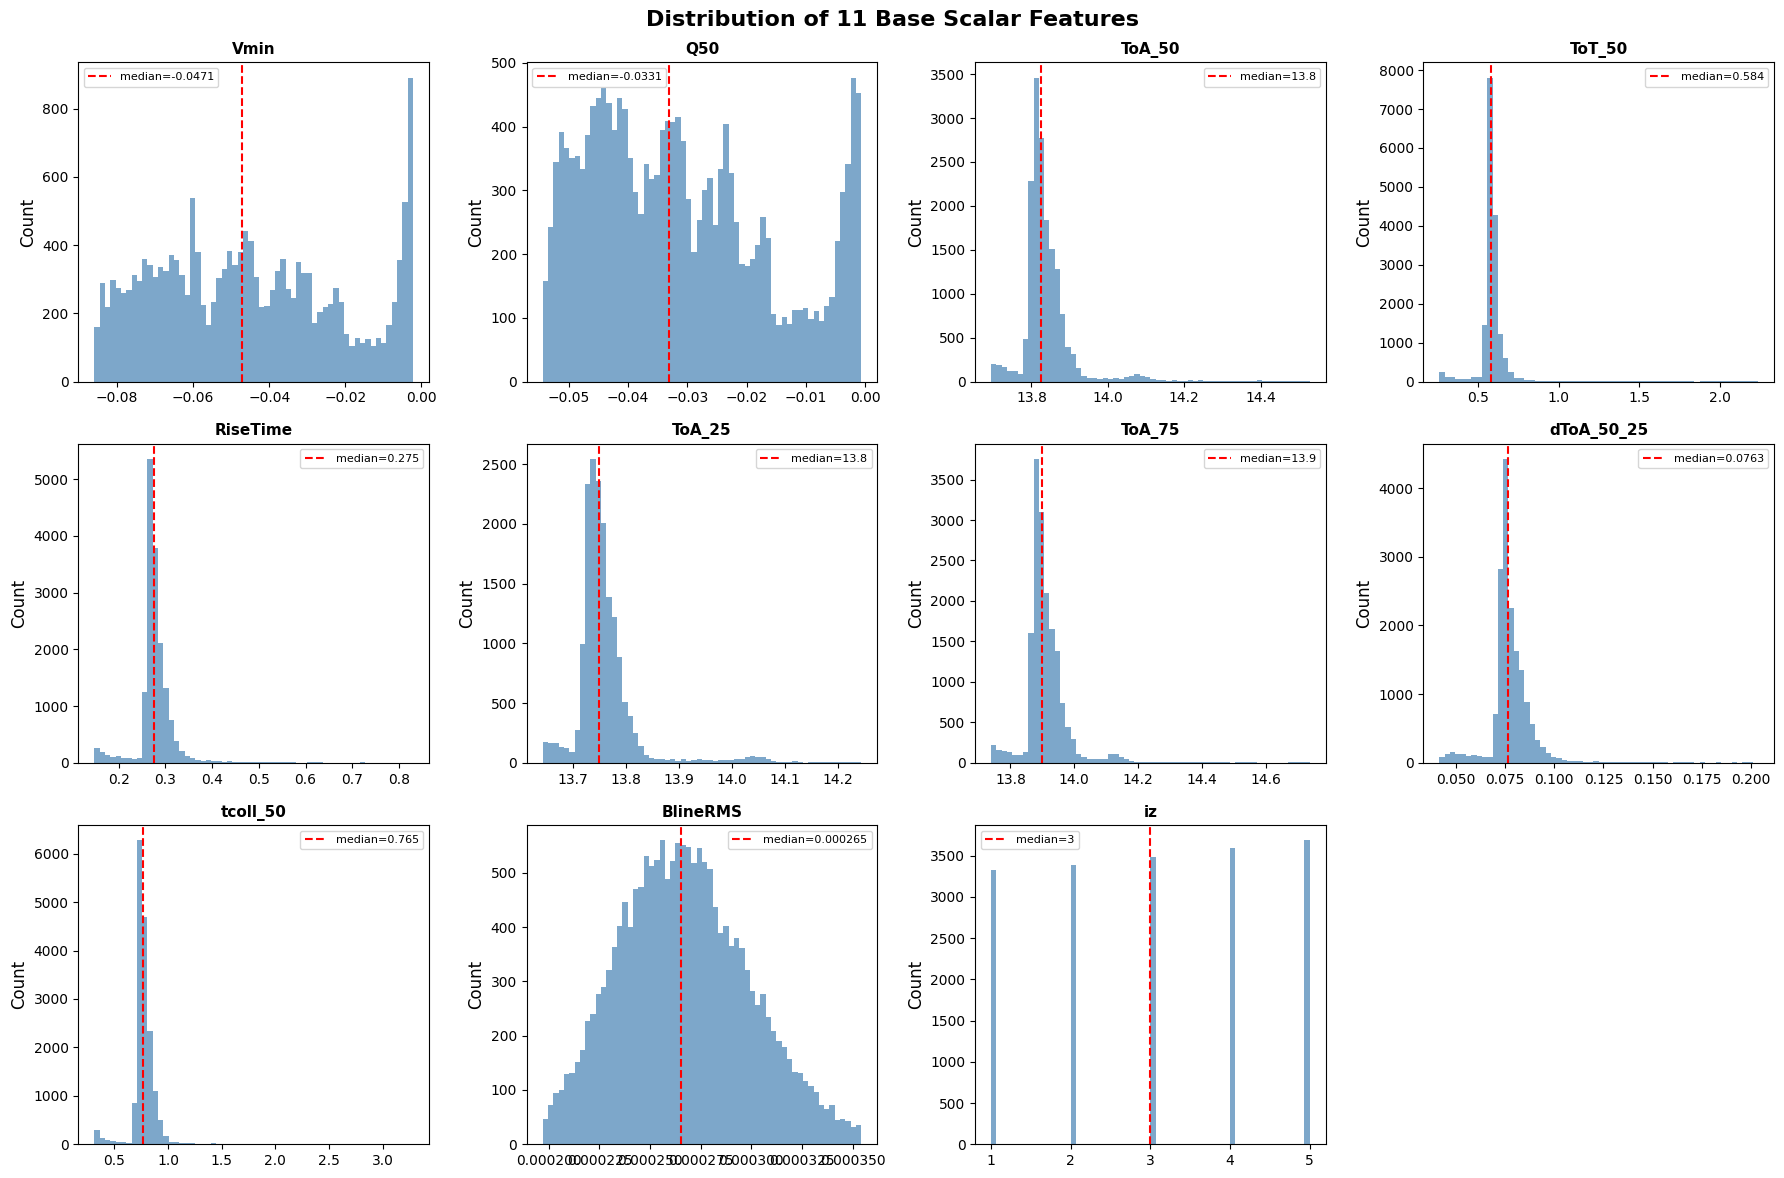


  Feature Summary Statistics:
  Feature              Mean        Std        Min        Max
  ------------------------------------------------------
  Vmin              -0.0453     0.0247    -0.0949    -0.0020
  Q50               -0.0308     0.0155    -0.0604     0.0005
  ToA_50            13.8669     0.4611    13.6566    24.5057
  ToT_50             0.6167     0.2715     0.2177     4.3053
  RiseTime           0.2910     0.1294    -0.8077     3.4922
  ToA_25            13.7859     0.4556    13.4615    24.4390
  ToA_75            13.9442     0.4676    13.6924    24.5722
  dToA_50_25         0.0809     0.0344     0.0305     1.1147
  tcoll_50           0.8336     0.5732     0.2414    11.1938
  BlineRMS           0.0003     0.0000     0.0002     0.0004
  iz                 3.0525     1.4150     1.0000     5.0000


In [2]:
# ============================================================
# §2a  Feature distributions — 3x4 histogram grid
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, name in enumerate(feature_names):
    ax = axes[i]
    vals = features[:, i]
    p1, p99 = np.percentile(vals, [1, 99])
    ax.hist(vals, bins=60, range=(p1, p99), alpha=0.7,
            color='steelblue', edgecolor='none')
    ax.axvline(np.median(vals), color='red', ls='--', lw=1.5,
               label=f'median={np.median(vals):.3g}')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Count')

axes[-1].axis('off')  # empty slot
plt.suptitle('Distribution of 11 Base Scalar Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics table
print("\n  Feature Summary Statistics:")
print(f"  {'Feature':<14} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print(f"  {'-'*54}")
for i, name in enumerate(feature_names):
    v = features[:, i]
    print(f"  {name:<14} {v.mean():>10.4f} {v.std():>10.4f} {v.min():>10.4f} {v.max():>10.4f}")

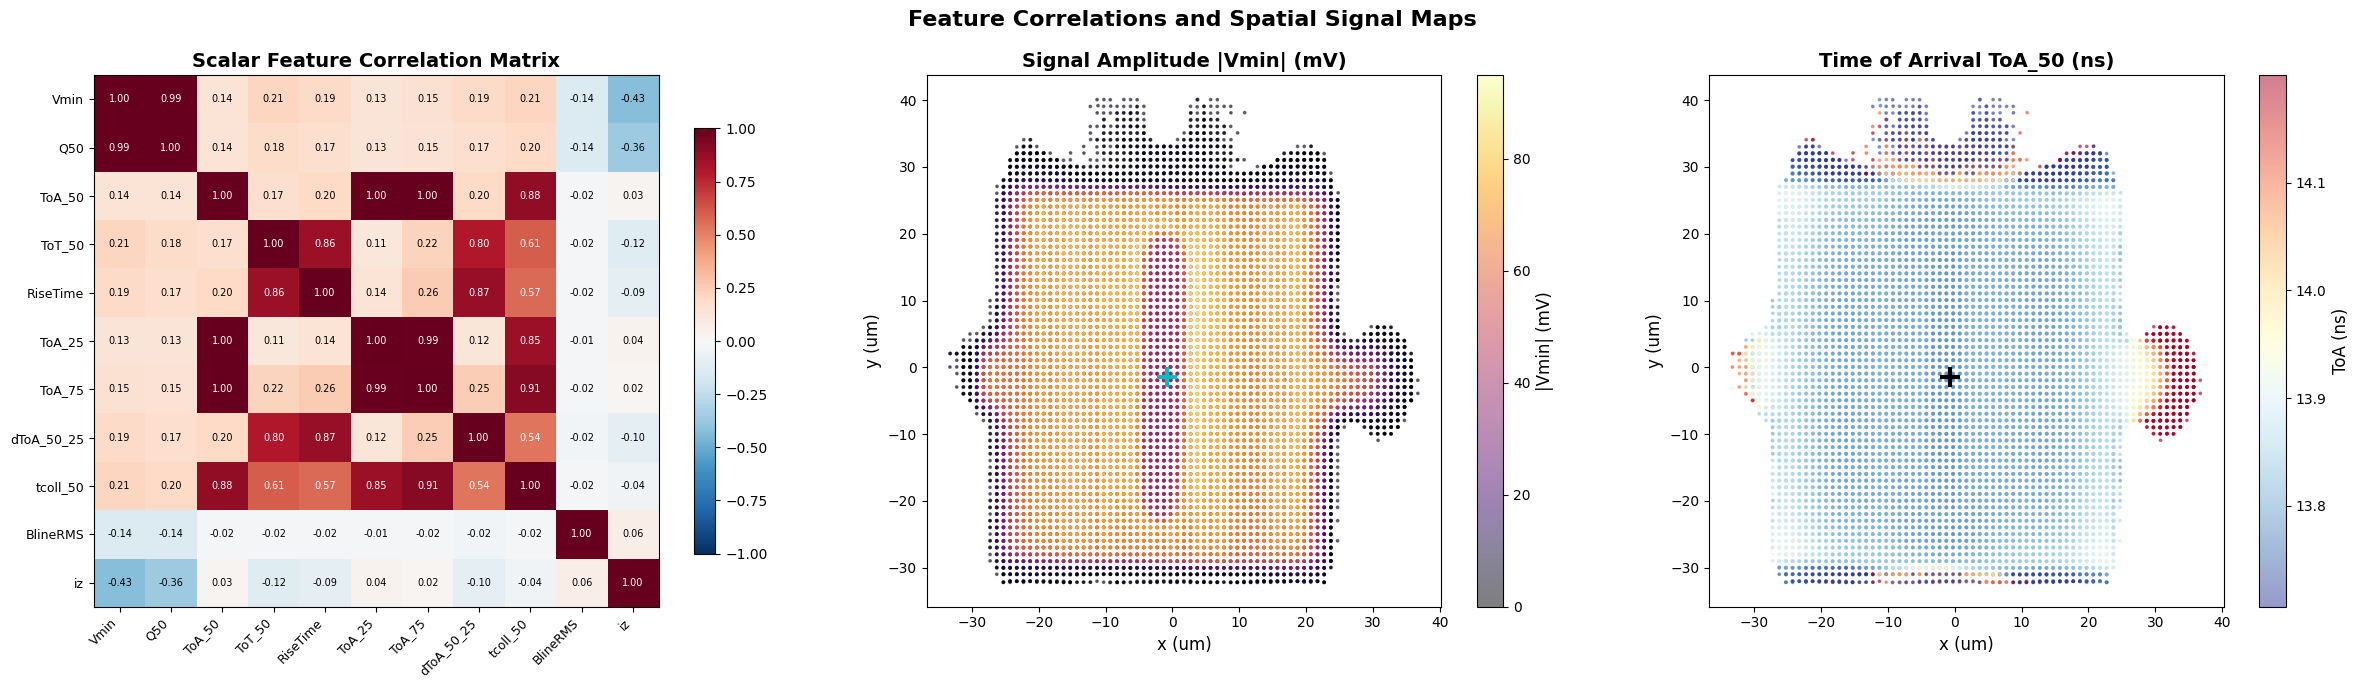


Key observations:
  - Vmin, Q50, and ToA features are strongly correlated (encode radial distance)
  - Spatial maps show clear pixel structure with signal peak at center
  - Amplitude is C2v-symmetric: identical at mirror-related positions
  - This symmetry creates the quadrant ambiguity we must resolve


In [3]:
# ============================================================
# §2b  Correlation matrix + Spatial signal maps
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- Correlation matrix ---
ax = axes[0]
corr = np.corrcoef(features.T)
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(N_SCALARS))
ax.set_yticks(range(N_SCALARS))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(feature_names, fontsize=9)
for i in range(N_SCALARS):
    for j in range(N_SCALARS):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(corr[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Scalar Feature Correlation Matrix', fontweight='bold')

# --- Spatial amplitude map (|Vmin|) ---
x_um, y_um = targets_xy[:, 0], targets_xy[:, 1]
ax = axes[1]
sc = ax.scatter(x_um, y_um, c=np.abs(features[:, 0]) * 1000,
                s=3, alpha=0.5, cmap='inferno', vmin=0)
ax.plot(X_C, Y_C, 'c+', ms=15, mew=3)
ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
ax.set_aspect('equal')
ax.set_title('Signal Amplitude |Vmin| (mV)', fontweight='bold')
plt.colorbar(sc, ax=ax, label='|Vmin| (mV)')

# --- Spatial ToA map ---
ax = axes[2]
toa = features[:, 2]  # ToA_50
p2, p98 = np.percentile(toa, [2, 98])
sc = ax.scatter(x_um, y_um, c=toa, s=3, alpha=0.5,
                cmap='RdYlBu_r', vmin=p2, vmax=p98)
ax.plot(X_C, Y_C, 'k+', ms=15, mew=3)
ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
ax.set_aspect('equal')
ax.set_title('Time of Arrival ToA_50 (ns)', fontweight='bold')
plt.colorbar(sc, ax=ax, label='ToA (ns)')

plt.suptitle('Feature Correlations and Spatial Signal Maps', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}fig_correlation_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observations:")
print("  - Vmin, Q50, and ToA features are strongly correlated (encode radial distance)")
print("  - Spatial maps show clear pixel structure with signal peak at center")
print("  - Amplitude is C2v-symmetric: identical at mirror-related positions")
print("  - This symmetry creates the quadrant ambiguity we must resolve")

## §3  Waveform Preprocessing and Derivative/FFT Channels

### Peak-Aligned ROI Waveforms
The raw TPA-TCT waveforms (1000 samples at 20 GS/s) undergo:
1. **Temporal cropping** to [200:500] (300 samples, 15 ns window containing the signal)
2. **Baseline restoration**: subtract mean of first 20 samples
3. **Peak alignment**: detect `argmin(V(t))` and extract a symmetric ROI of [peak−30 : peak+60] = **90 bins**

This alignment eliminates temporal jitter from the trigger system and ensures the CNN 
sees shape information in a consistent temporal reference frame.

### Derivative Channel (dV/dt)
The numerical derivative `dV/dt = np.gradient(V(t))` amplifies timing features — the 
rising and falling edges of the current pulse — which are sensitive to the local electric 
field geometry and thus to position.

### FFT Magnitude Spectrum
The magnitude of the discrete Fourier transform |FFT(V(t))| captures frequency-domain 
information (oscillation modes, pulse shape spectral content) that complements the 
time-domain representation.

Together, these provide three complementary views of the same physical signal.

Derivative: (17473, 90)
FFT:        (17473, 46)  (46 frequency bins)


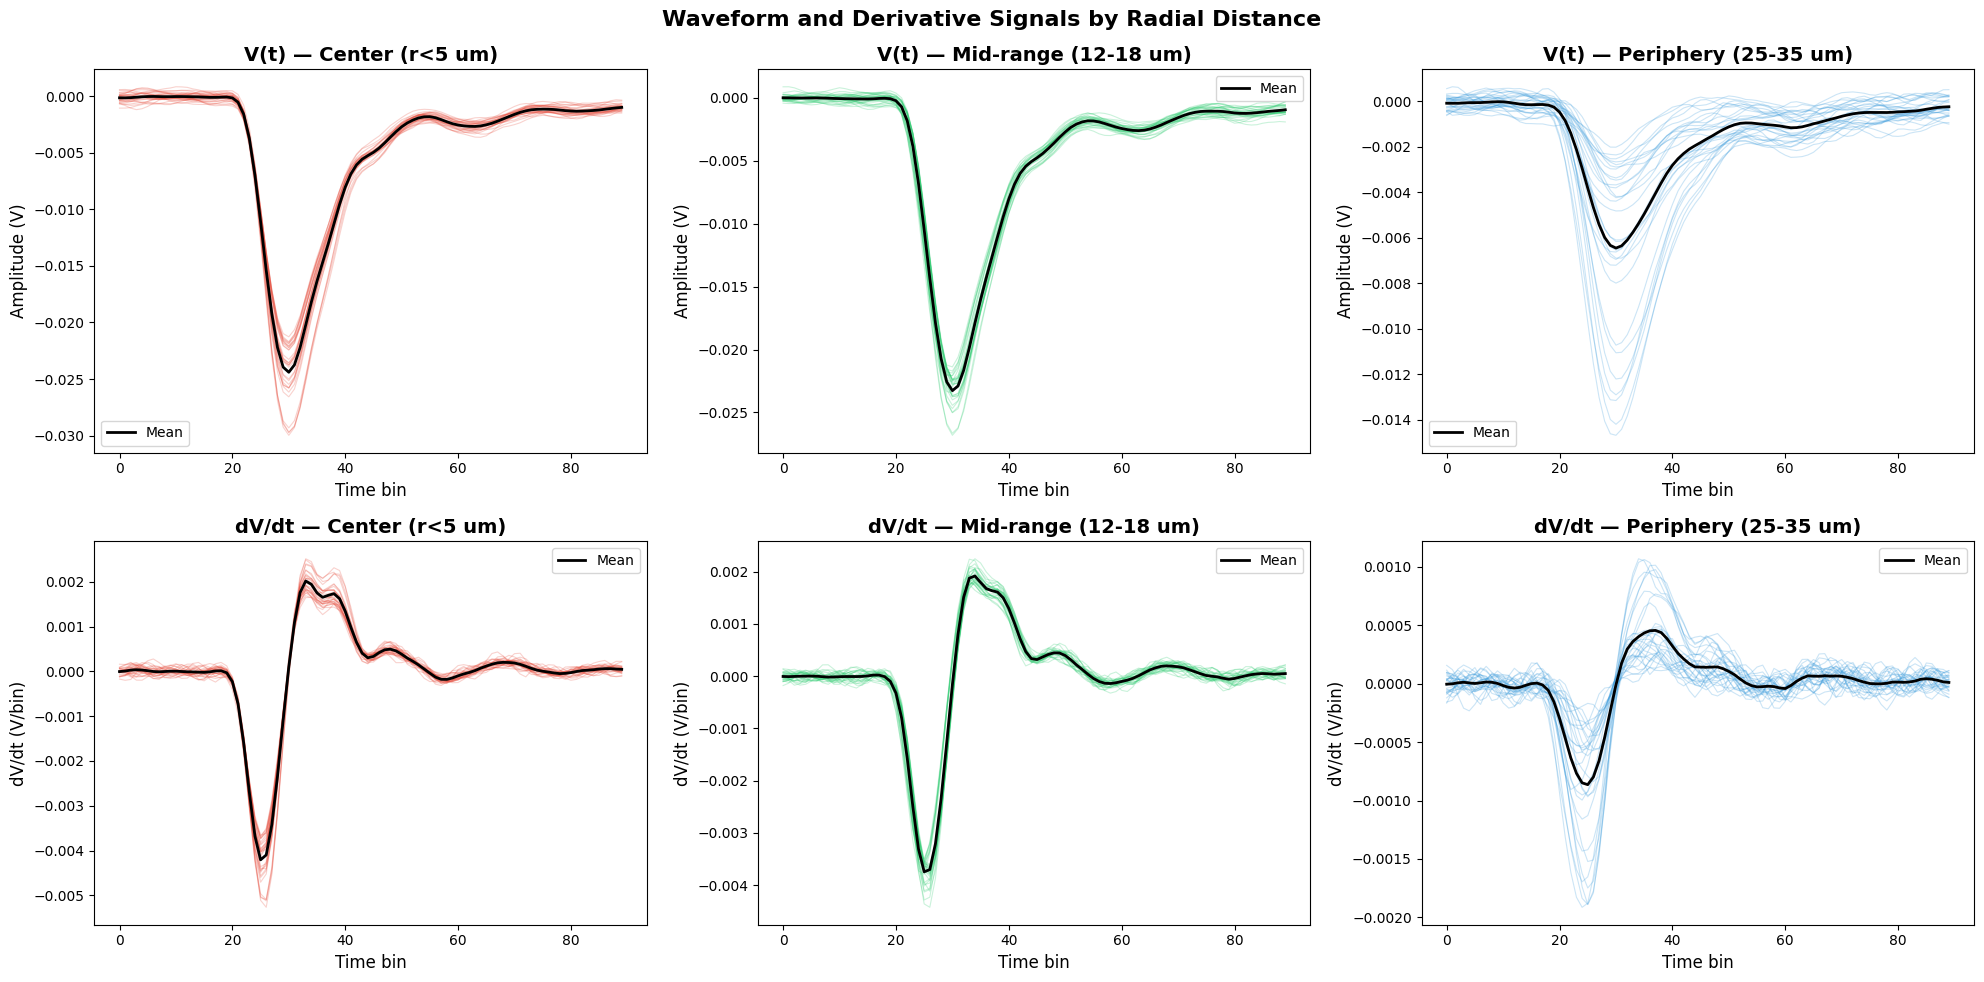

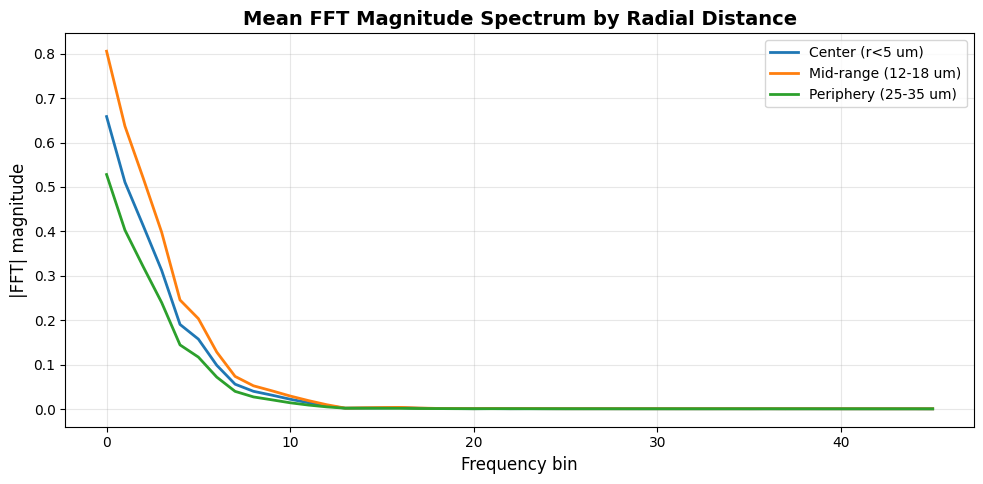


Observations:
  - Center events have weaker, broader pulses (lower charge collection efficiency)
  - Periphery events show sharper, stronger pulses with distinct timing
  - The derivative channel enhances rising/falling edge differences
  - FFT shows different spectral content between center and periphery


In [4]:
# ============================================================
# §3a  Derivative and FFT computation + waveform visualization
# ============================================================

# --- Compute derivative and FFT ---
deriv_roi = np.gradient(wf_roi, axis=1)                     # (N, 90)
fft_roi = np.abs(np.fft.rfft(wf_roi, axis=1))              # (N, 46)
N_FFT_BINS = fft_roi.shape[1]

print(f"Derivative: {deriv_roi.shape}")
print(f"FFT:        {fft_roi.shape}  ({N_FFT_BINS} frequency bins)")

# --- Visualization: example waveforms from different positions ---
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Select events from different radial distances
r_all = np.sqrt((x_um - X_C)**2 + (y_um - Y_C)**2)
r_bins = [(0, 5, 'Center (r<5 um)'), (12, 18, 'Mid-range (12-18 um)'),
          (25, 35, 'Periphery (25-35 um)')]
colors = ['#e74c3c', '#2ecc71', '#3498db']

for col, (r_lo, r_hi, label) in enumerate(r_bins):
    mask = (r_all >= r_lo) & (r_all < r_hi)
    idxs = np.where(mask)[0][:30]  # up to 30 examples

    # Waveforms
    ax = axes[0, col]
    for i in idxs:
        ax.plot(wf_roi[i], alpha=0.25, color=colors[col], lw=0.8)
    ax.plot(wf_roi[idxs].mean(axis=0), 'k-', lw=2, label='Mean')
    ax.set_title(f'V(t) — {label}', fontweight='bold')
    ax.set_xlabel('Time bin')
    ax.set_ylabel('Amplitude (V)')
    ax.legend()

    # Derivatives
    ax = axes[1, col]
    for i in idxs:
        ax.plot(deriv_roi[i], alpha=0.25, color=colors[col], lw=0.8)
    ax.plot(deriv_roi[idxs].mean(axis=0), 'k-', lw=2, label='Mean')
    ax.set_title(f'dV/dt — {label}', fontweight='bold')
    ax.set_xlabel('Time bin')
    ax.set_ylabel('dV/dt (V/bin)')
    ax.legend()

plt.suptitle('Waveform and Derivative Signals by Radial Distance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}fig_waveform_examples.png', dpi=150, bbox_inches='tight')
plt.show()

# --- FFT comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
for r_lo, r_hi, label in r_bins:
    mask = (r_all >= r_lo) & (r_all < r_hi)
    mean_fft = fft_roi[mask].mean(axis=0)
    ax.plot(mean_fft, lw=2, label=label)
ax.set_xlabel('Frequency bin')
ax.set_ylabel('|FFT| magnitude')
ax.set_title('Mean FFT Magnitude Spectrum by Radial Distance', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}fig_fft_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservations:")
print("  - Center events have weaker, broader pulses (lower charge collection efficiency)")
print("  - Periphery events show sharper, stronger pulses with distinct timing")
print("  - The derivative channel enhances rising/falling edge differences")
print("  - FFT shows different spectral content between center and periphery")

## §4  C₂v Symmetry Framework

### The Quadrant Ambiguity Problem

The 3D-trench pixel has **C₂v point-group symmetry** with four symmetry operations:

| Operation | Symbol | Effect | Matrix |
|-----------|--------|--------|--------|
| Identity | E | No change | diag(1, 1) |
| 180° rotation | C₂ | (u,v) → (−u, −v) | diag(−1, −1) |
| Mirror σᵥ(u) | σᵥ | (u,v) → (u, −v) | diag(1, −1) |
| Mirror σᵥ'(v) | σᵥ' | (u,v) → (−u, v) | diag(−1, 1) |

where (u, v) are coordinates aligned with trench axes, rotated by φ₀ ≈ 89.27° from (x, y).

Each physical position maps to four **symmetry-equivalent positions** in four quadrants:
- **Q0** = (u≥0, v≥0), **Q1** = (u≥0, v<0), **Q2** = (u<0, v<0), **Q3** = (u<0, v≥0)

The waveforms at these four positions are *nearly identical* because the electric field 
configuration is symmetric. The task is to determine which quadrant the event belongs to 
despite this degeneracy.

### Key Insight: C₂v Irreducible Representations

The C₂v character table defines how signals transform under symmetry:

| Irrep | E | C₂ | σᵥ(u) | σᵥ'(v) | Discriminates |
|-------|---|-----|--------|---------|---------------|
| A₁ | +1 | +1 | +1 | +1 | Nothing (symmetric mean) |
| **B₂** | **+1** | **−1** | **−1** | **+1** | **u-sign** ← Primary target |
| B₁ | +1 | −1 | +1 | −1 | v-sign |
| A₂ | +1 | +1 | −1 | −1 | Cross-channel |

The **B₂ projection** = (μ₀ + μ₁ − μ₂ − μ₃)/4 isolates the component that changes sign 
under u-reflection, exactly discriminating Q0/Q1 from Q2/Q3. This is the theoretical 
foundation for our C₂v irrep features.

C2v Coordinate System:
  Center: (-0.75, -1.46) um | phi0 = 89.27 deg
  Fundamental domain: |u| in [0.00, 41.61]
                      |v| in [0.02, 37.52] um

Quadrant distribution: {np.int64(0): np.int64(4466), np.int64(1): np.int64(4639), np.int64(2): np.int64(4295), np.int64(3): np.int64(4073)}
U-sign: u+ = 9105 | u- = 8368

Spatial groups: 1081 (median 20 events/group)


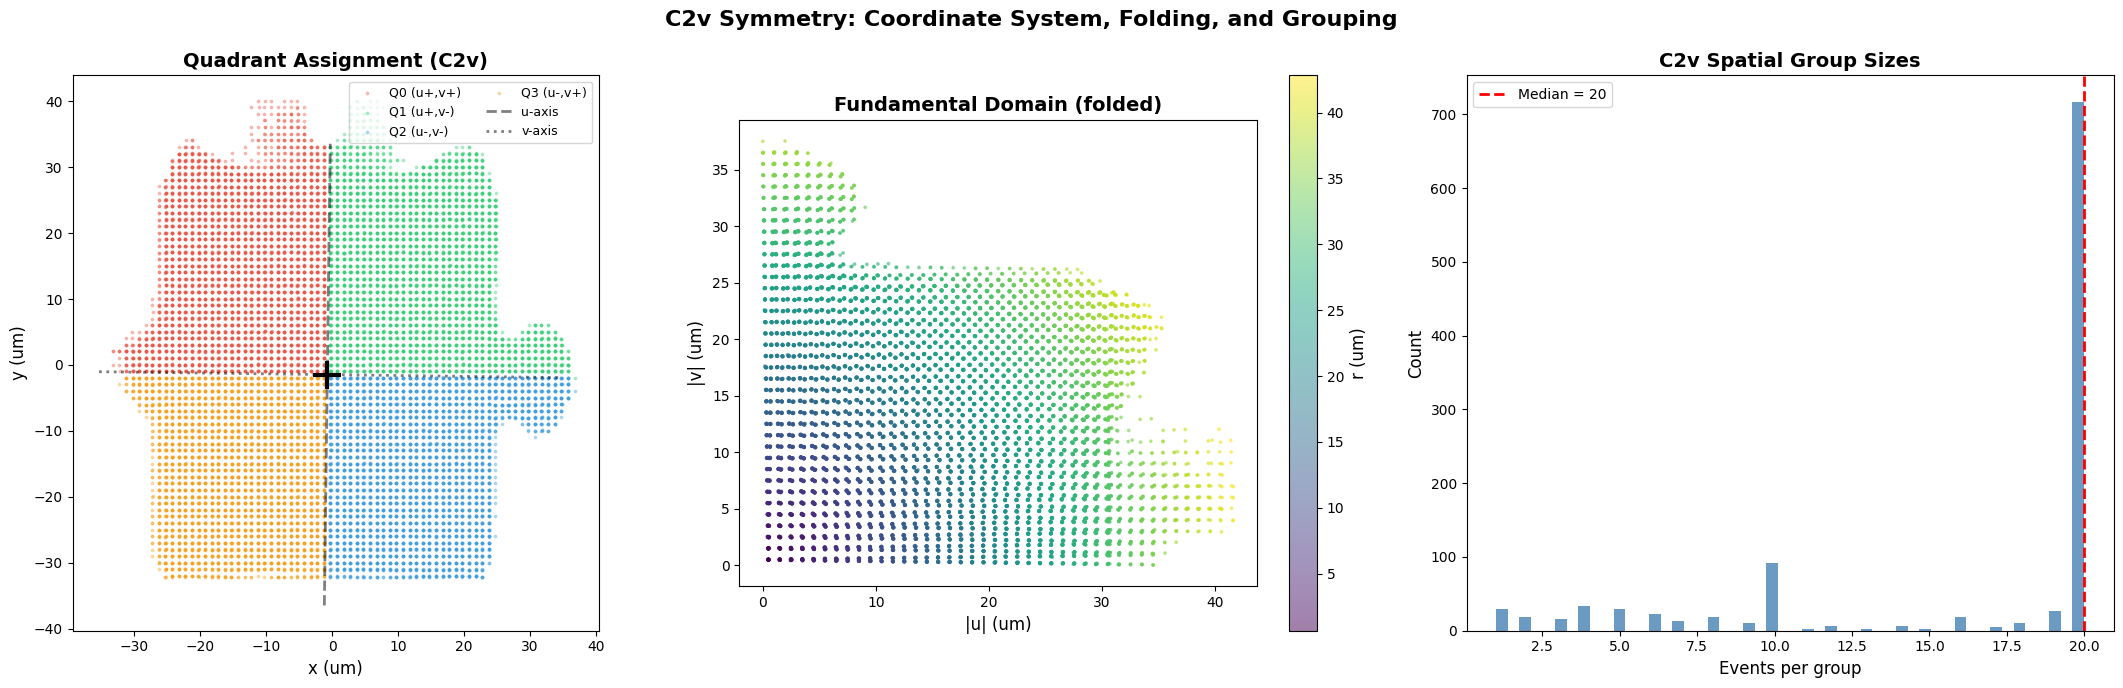

In [5]:
# ============================================================
# §4a  C2v coordinate system and quadrant assignment
# ============================================================

# Rotated coordinates aligned with trench axes
phi_r = np.radians(PHI0)
dx_c, dy_c = x_um - X_C, y_um - Y_C
u_all =  np.cos(phi_r) * dx_c + np.sin(phi_r) * dy_c   # parallel to trench
v_all = -np.sin(phi_r) * dx_c + np.cos(phi_r) * dy_c   # perpendicular to trench

# Fundamental domain: fold to (|u|, |v|)
xf_all = np.abs(u_all)  # |u|
yf_all = np.abs(v_all)  # |v|
r_all = np.sqrt(xf_all**2 + yf_all**2)

# Quadrant assignment: Q0=(u+,v+), Q1=(u+,v-), Q2=(u-,v-), Q3=(u-,v+)
q_all = np.zeros(N, dtype=int)
q_all[(u_all >= 0) & (v_all <  0)] = 1
q_all[(u_all <  0) & (v_all <  0)] = 2
q_all[(u_all <  0) & (v_all >= 0)] = 3

# U-sign label: 1 for u>=0 (Q0,Q1), 0 for u<0 (Q2,Q3)
u_sign_all = ((q_all == 0) | (q_all == 1)).astype(np.float32)

# C2v spatial groups: fold (|dx|, |dy|) from center
x_int = np.round(x_um).astype(int)
y_int = np.round(y_um).astype(int)
cx_int, cy_int = np.round(X_C).astype(int), np.round(Y_C).astype(int)
dx_abs = np.abs(x_int - cx_int)
dy_abs = np.abs(y_int - cy_int)

pos_groups = defaultdict(list)
for i in range(N):
    key = (int(dx_abs[i]), int(dy_abs[i]))
    pos_groups[key].append(i)

n_groups = len(pos_groups)
group_sizes = [len(v) for v in pos_groups.values()]

print(f"C2v Coordinate System:")
print(f"  Center: ({X_C:.2f}, {Y_C:.2f}) um | phi0 = {PHI0:.2f} deg")
print(f"  Fundamental domain: |u| in [{xf_all.min():.2f}, {xf_all.max():.2f}]")
print(f"                      |v| in [{yf_all.min():.2f}, {yf_all.max():.2f}] um")
print(f"\nQuadrant distribution: {dict(zip(*np.unique(q_all, return_counts=True)))}")
print(f"U-sign: u+ = {int(u_sign_all.sum())} | u- = {int((1-u_sign_all).sum())}")
print(f"\nSpatial groups: {n_groups} (median {np.median(group_sizes):.0f} events/group)")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Quadrant map
ax = axes[0]
q_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
q_labels = ['Q0 (u+,v+)', 'Q1 (u+,v-)', 'Q2 (u-,v-)', 'Q3 (u-,v+)']
for qi in range(4):
    mask = q_all == qi
    ax.scatter(x_um[mask], y_um[mask], c=q_colors[qi], s=3, alpha=0.3, label=q_labels[qi])
ax.plot(X_C, Y_C, 'k+', ms=20, mew=3, zorder=10)
# Draw symmetry axes
ax.plot([X_C - 35*np.cos(phi_r), X_C + 35*np.cos(phi_r)],
        [Y_C - 35*np.sin(phi_r), Y_C + 35*np.sin(phi_r)],
        'k--', lw=2, alpha=0.5, label='u-axis')
ax.plot([X_C + 35*np.sin(phi_r), X_C - 35*np.sin(phi_r)],
        [Y_C - 35*np.cos(phi_r), Y_C + 35*np.cos(phi_r)],
        'k:', lw=2, alpha=0.5, label='v-axis')
ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
ax.set_aspect('equal')
ax.legend(fontsize=9, ncol=2)
ax.set_title('Quadrant Assignment (C2v)', fontweight='bold')

# Fundamental domain
ax = axes[1]
sc = ax.scatter(xf_all, yf_all, c=r_all, s=3, alpha=0.5, cmap='viridis')
ax.set_xlabel('|u| (um)')
ax.set_ylabel('|v| (um)')
ax.set_aspect('equal')
ax.set_title('Fundamental Domain (folded)', fontweight='bold')
plt.colorbar(sc, ax=ax, label='r (um)')

# Group sizes
ax = axes[2]
ax.hist(group_sizes, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(np.median(group_sizes), color='red', ls='--', lw=2,
           label=f'Median = {np.median(group_sizes):.0f}')
ax.set_xlabel('Events per group')
ax.set_ylabel('Count')
ax.set_title('C2v Spatial Group Sizes', fontweight='bold')
ax.legend()

plt.suptitle('C2v Symmetry: Coordinate System, Folding, and Grouping',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}fig_c2v_framework.png', dpi=150, bbox_inches='tight')
plt.show()

## §5  Hierarchical Asymmetry PCA

### Motivation
Standard PCA on the full waveform dataset captures variance dominated by radial distance 
(centre vs. periphery). To isolate **position-dependent asymmetries** — the subtle 
differences between waveforms at symmetry-equivalent positions — we use a hierarchical 
approach:

1. **Group events** by C₂v-folded position, so each group contains events 
   from the same "orbit" of the symmetry group
2. **Subtract the group mean** — this removes the radially-symmetric component (A₁ irrep), 
   leaving only asymmetric residuals
3. **Local PCA** (k=10 components) within each group captures the dominant within-group 
   variation modes
4. **Global PCA** on stacked local eigenvectors finds **universal master modes** that 
   describe asymmetric variation across all positions

### Grouping strategies
Two different C₂v groupings are used to match the original NB20 pipeline:

- **Waveform domain**: uses **scan-index grouping** — positions are ranked by their 
  discrete scan coordinates and folded around the scan grid center `(ix_min+ix_max)/2`. 
  This matches NB01's original computation that generated `tpa_tct_asym_modes.npz`.
- **Derivative and FFT domains**: use **physical-coord grouping** — positions are 
  rounded to the nearest µm and folded around the pixel geometry center `(X_C, Y_C)`. 
  This matches buenoo/NB20's §2 computation.

### Signal domains
- **Waveform** V(t): 25 modes (scan-index groups)
- **Derivative** dV/dt: 25 modes (physical-coord groups)
- **FFT** |FFT(V)|: 15 modes (physical-coord groups)

The derivative domain deserved more modes because its local structure is richer — with only 
15 modes it captured only ~63.7% of variance, vs. ~83.5% with 25 modes.

Hierarchical Asymmetry PCA Results:
  Scan-index grouping (for waveform): 1175 groups, median 17 ev/group
  Physical-coord grouping (for dV/dt, FFT): 1081 groups, median 20 ev/group

  Waveform domain: 25 modes (scan-index groups)
    Valid groups: 1144/1175
    Eigenvectors collected: 10525
    Variance captured: 96.0%

  Derivative domain: 25 modes (physical-coord groups)
    Valid groups: 1018/1081
    Eigenvectors collected: 9436
    Variance captured: 83.5%

  FFT domain: 15 modes (physical-coord groups)
    Valid groups: 1018/1081
    Eigenvectors collected: 9436
    Variance captured: 95.9%

  Variance captured vs. number of modes:
   n_modes   Waveform      dV/dt        FFT
        10      75.7%      50.2%      81.9%
        15      88.2%      63.7%      95.9%
        20      92.7%      74.6%      95.9%
        25      96.0%      83.5%      95.9%
        30      98.1%      89.3%      95.9%


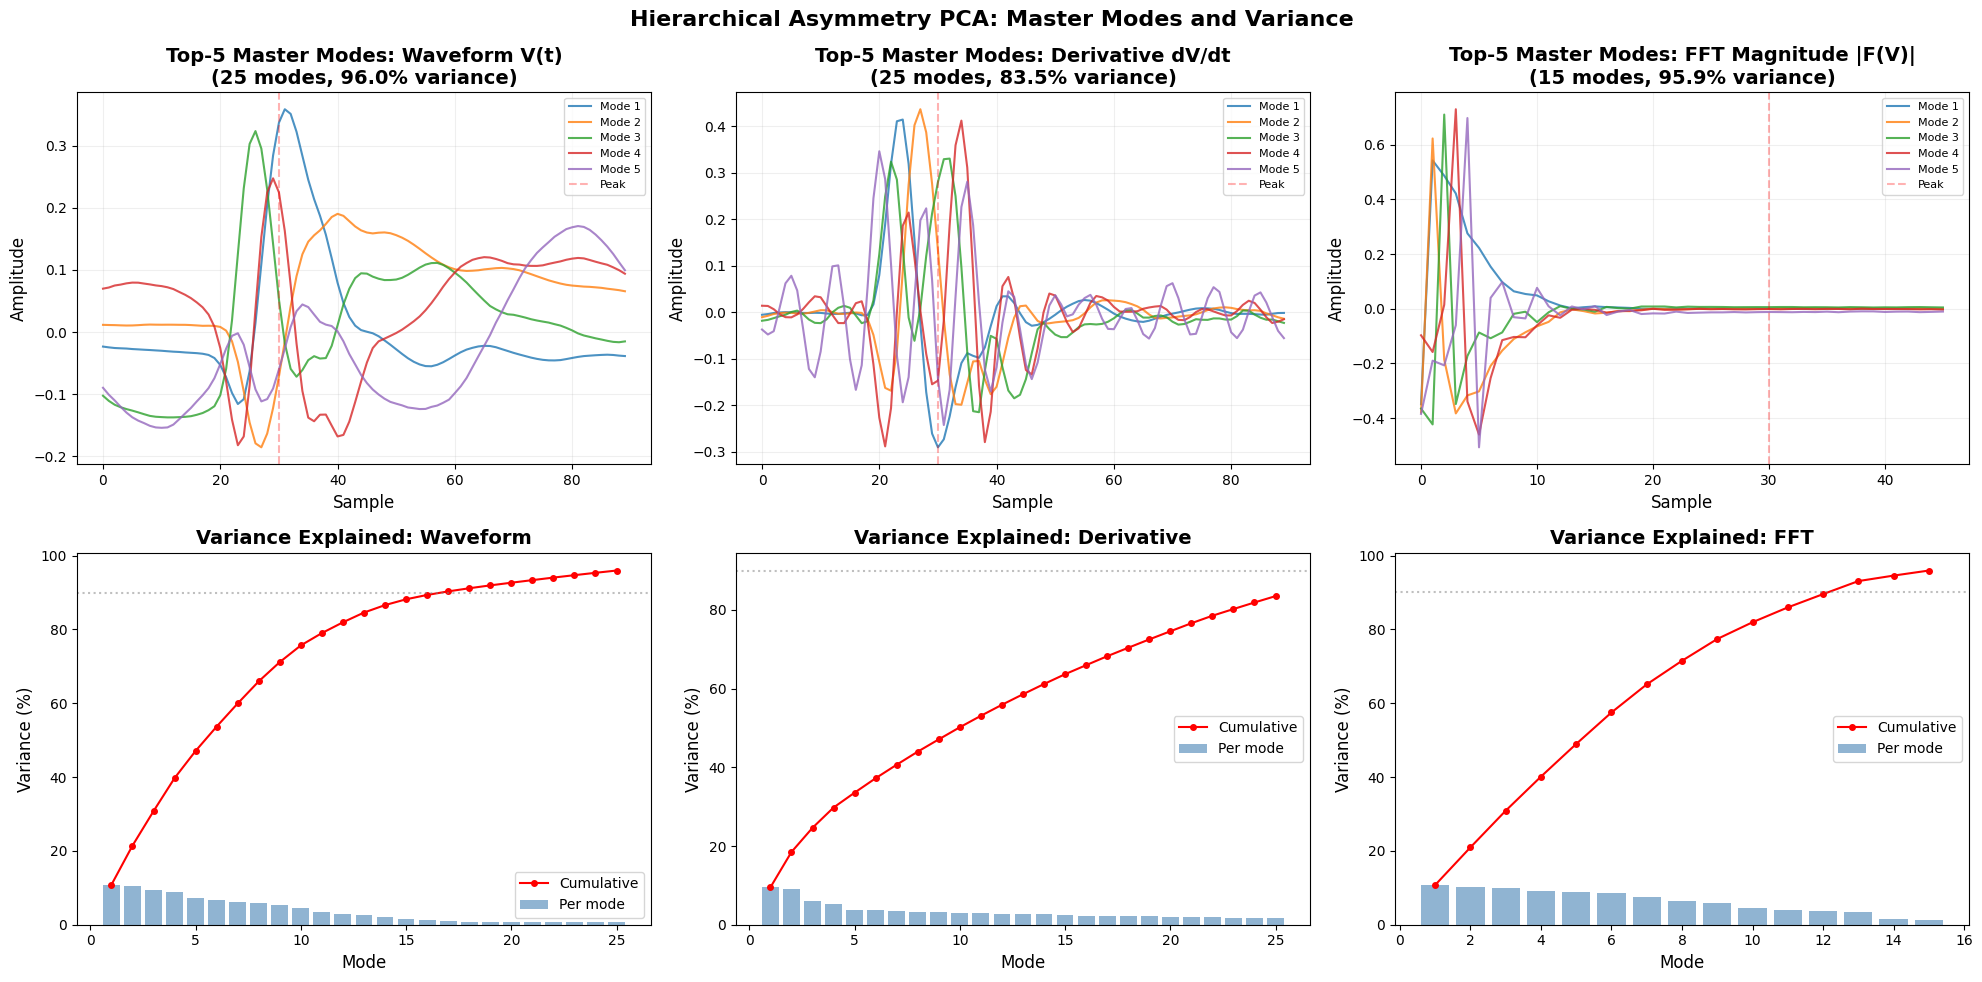

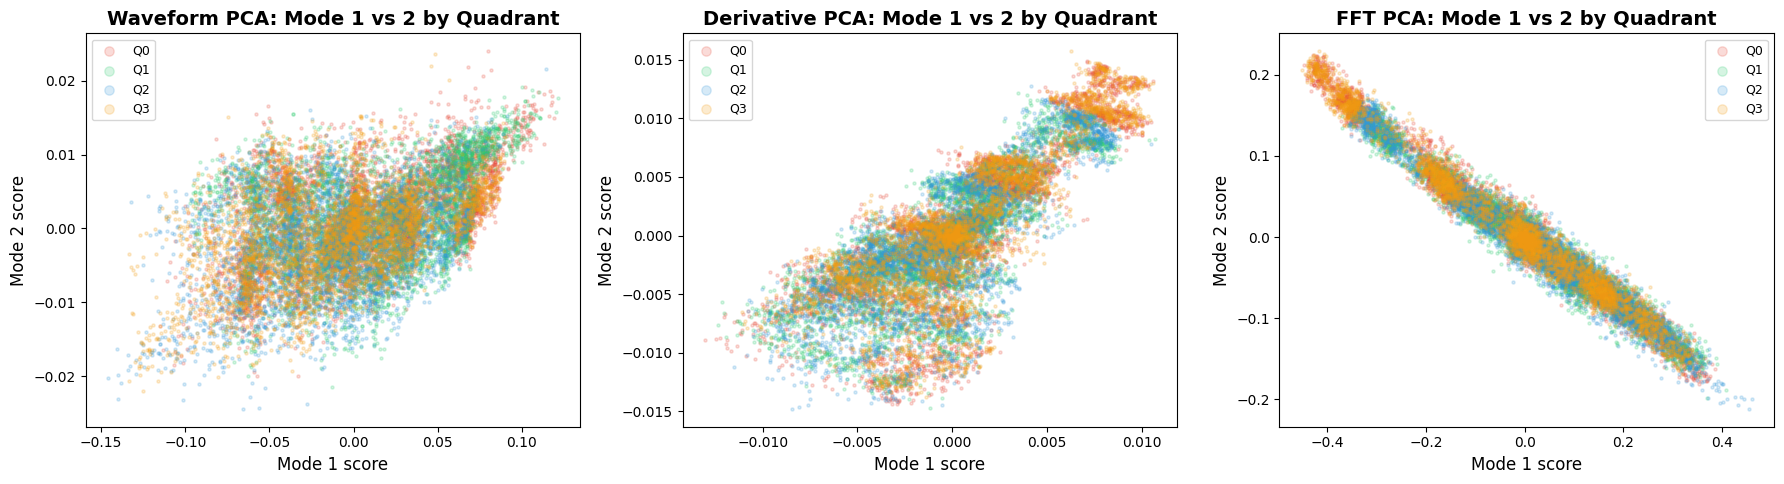


Key findings:
  - Waveform PCA uses scan-index grouping (matches NB01 pre-computed modes)
  - dV/dt and FFT PCA use physical-coord grouping (matches buenoo §2)
  - dV/dt PCA captures richer asymmetric structure (needs 25 modes)
  - FFT domain saturates quickly (15 modes)
  - PCA scores show partial quadrant separation, strongest in Mode 1


In [6]:
# ============================================================
# §5a  Hierarchical Asymmetry PCA — all three domains
# ============================================================

def hierarchical_asym_pca(signal_matrix, pos_groups, k_local=10,
                          n_asym=15, min_events=4):
    """
    Hierarchical PCA for C2v asymmetry extraction.
    
    1. For each spatial group: subtract group mean, fit local PCA (k components)
    2. Stack all local eigenvectors, fit global PCA → master modes
    3. Project event residuals onto master modes → asymmetry scores
    
    Returns: scores (N, n_asym), info dict
    """
    D = signal_matrix.shape[1]
    all_components = []
    valid_groups = 0

    for key, indices in pos_groups.items():
        n_ev = len(indices)
        if n_ev < min_events:
            continue
        wfs = signal_matrix[indices]
        wfs_centered = wfs - wfs.mean(axis=0, keepdims=True)
        n_comp = min(k_local, n_ev - 1, D)
        if n_comp < 1:
            continue
        local_pca = PCA(n_components=n_comp)
        local_pca.fit(wfs_centered)
        all_components.append(local_pca.components_)
        valid_groups += 1

    if valid_groups == 0:
        raise RuntimeError("0 groups processed for PCA!")
    all_comp = np.vstack(all_components)

    # Global PCA on stacked eigenvectors
    pca_global = PCA(n_components=min(n_asym, all_comp.shape[0]))
    pca_global.fit(all_comp)
    master_modes = pca_global.components_

    # Project residuals
    N_total = signal_matrix.shape[0]
    residuals = np.zeros_like(signal_matrix)
    for key, indices in pos_groups.items():
        mean_sig = signal_matrix[indices].mean(axis=0)
        for i in indices:
            residuals[i] = signal_matrix[i] - mean_sig

    scores = residuals @ master_modes.T

    info = {
        'valid_groups': valid_groups,
        'n_eigvecs': all_comp.shape[0],
        'var_total': pca_global.explained_variance_ratio_.sum(),
        'var_per_mode': pca_global.explained_variance_ratio_,
        'master_modes': master_modes,
    }
    return scores, info


# --- Hyperparameters ---
N_ASYM_WF    = 25     # Waveform domain
N_ASYM_DERIV = 25     # Derivative domain (matches NB20 original)
N_ASYM_FFT   = 15     # FFT domain (saturates at 95.9% with 15)

# --- Scan-index-based grouping for waveform PCA ---
# NB01 computed waveform asymmetry modes using the raw scan indices (ix, iy)
# from the ROOT file, folded around the scan grid center.
# Since ix/iy are not in the CSV, we reconstruct them by ranking the
# rounded physical coordinates → equivalent integer scan indices.
x_rounded = np.round(x_um).astype(int)
y_rounded = np.round(y_um).astype(int)
x_unique_sorted = np.sort(np.unique(x_rounded))
y_unique_sorted = np.sort(np.unique(y_rounded))
ix_map = {v: i for i, v in enumerate(x_unique_sorted)}
iy_map = {v: i for i, v in enumerate(y_unique_sorted)}
ix_inferred = np.array([ix_map[x_rounded[i]] for i in range(N)])
iy_inferred = np.array([iy_map[y_rounded[i]] for i in range(N)])
ix_center = (ix_inferred.min() + ix_inferred.max()) / 2.0
iy_center = (iy_inferred.min() + iy_inferred.max()) / 2.0
dix_abs = np.abs(ix_inferred - ix_center).astype(int)
diy_abs = np.abs(iy_inferred - iy_center).astype(int)

pos_groups_scan = defaultdict(list)
for i in range(N):
    pos_groups_scan[(int(dix_abs[i]), int(diy_abs[i]))].append(i)
n_groups_scan = len(pos_groups_scan)

print("Hierarchical Asymmetry PCA Results:")
print("=" * 60)
print(f"  Scan-index grouping (for waveform): {n_groups_scan} groups, "
      f"median {np.median([len(v) for v in pos_groups_scan.values()]):.0f} ev/group")
print(f"  Physical-coord grouping (for dV/dt, FFT): {n_groups} groups, "
      f"median {np.median(group_sizes):.0f} ev/group")

# --- Waveform domain (using scan-index grouping, matching NB01) ---
print(f"\n  Waveform domain: {N_ASYM_WF} modes (scan-index groups)")
asym_wf, info_wf = hierarchical_asym_pca(
    wf_roi, pos_groups_scan, k_local=10, n_asym=N_ASYM_WF)
print(f"    Valid groups: {info_wf['valid_groups']}/{n_groups_scan}")
print(f"    Eigenvectors collected: {info_wf['n_eigvecs']}")
print(f"    Variance captured: {info_wf['var_total']*100:.1f}%")

# --- Derivative domain (using physical-coord grouping, matching buenoo §2) ---
print(f"\n  Derivative domain: {N_ASYM_DERIV} modes (physical-coord groups)")
asym_deriv, info_deriv = hierarchical_asym_pca(
    deriv_roi, pos_groups, k_local=10, n_asym=N_ASYM_DERIV)
print(f"    Valid groups: {info_deriv['valid_groups']}/{n_groups}")
print(f"    Eigenvectors collected: {info_deriv['n_eigvecs']}")
print(f"    Variance captured: {info_deriv['var_total']*100:.1f}%")

# --- FFT domain (using physical-coord grouping, matching buenoo §2) ---
print(f"\n  FFT domain: {N_ASYM_FFT} modes (physical-coord groups)")
asym_fft, info_fft = hierarchical_asym_pca(
    fft_roi, pos_groups, k_local=10, n_asym=N_ASYM_FFT)
print(f"    Valid groups: {info_fft['valid_groups']}/{n_groups}")
print(f"    Eigenvectors collected: {info_fft['n_eigvecs']}")
print(f"    Variance captured: {info_fft['var_total']*100:.1f}%")

# --- Variance analysis: why 25 for dV/dt? ---
print("\n  Variance captured vs. number of modes:")
print(f"  {'n_modes':>8} {'Waveform':>10} {'dV/dt':>10} {'FFT':>10}")
for n_test in [10, 15, 20, 25, 30]:
    _, info_w = hierarchical_asym_pca(wf_roi, pos_groups_scan, n_asym=n_test)
    _, info_d = hierarchical_asym_pca(deriv_roi, pos_groups, n_asym=n_test)
    _, info_f = hierarchical_asym_pca(fft_roi, pos_groups, n_asym=min(n_test, N_ASYM_FFT))
    print(f"  {n_test:>8} {info_w['var_total']*100:>9.1f}% "
          f"{info_d['var_total']*100:>9.1f}% {info_f['var_total']*100:>9.1f}%")

# --- Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Top: master mode shapes
for col, (info, title, n_modes) in enumerate([
    (info_wf, 'Waveform V(t)', N_ASYM_WF),
    (info_deriv, 'Derivative dV/dt', N_ASYM_DERIV),
    (info_fft, 'FFT Magnitude |F(V)|', N_ASYM_FFT)]):
    ax = axes[0, col]
    modes = info['master_modes']
    for m in range(min(5, len(modes))):
        ax.plot(modes[m], label=f'Mode {m+1}', lw=1.5, alpha=0.8)
    ax.axvline(30, color='red', ls='--', alpha=0.3, label='Peak')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Top-5 Master Modes: {title}\n({n_modes} modes, '
                 f'{info["var_total"]*100:.1f}% variance)', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

# Bottom: variance explained
for col, (info, title) in enumerate([
    (info_wf, 'Waveform'),
    (info_deriv, 'Derivative'),
    (info_fft, 'FFT')]):
    ax = axes[1, col]
    var = info['var_per_mode']
    cumvar = np.cumsum(var) * 100
    ax.bar(range(1, len(var)+1), var*100, alpha=0.6, color='steelblue', label='Per mode')
    ax.plot(range(1, len(var)+1), cumvar, 'r-o', ms=4, label='Cumulative')
    ax.axhline(90, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('Mode')
    ax.set_ylabel('Variance (%)')
    ax.set_title(f'Variance Explained: {title}', fontweight='bold')
    ax.legend()

plt.suptitle('Hierarchical Asymmetry PCA: Master Modes and Variance',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}fig_pca_modes_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- PCA score distributions by quadrant ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
q_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
q_labels = ['Q0', 'Q1', 'Q2', 'Q3']

for col, (scores, title) in enumerate([
    (asym_wf, 'Waveform'), (asym_deriv, 'Derivative'), (asym_fft, 'FFT')]):
    ax = axes[col]
    for qi in range(4):
        mask = q_all == qi
        ax.scatter(scores[mask, 0], scores[mask, 1], c=q_colors[qi],
                   s=5, alpha=0.2, label=q_labels[qi])
    ax.set_xlabel('Mode 1 score')
    ax.set_ylabel('Mode 2 score')
    ax.set_title(f'{title} PCA: Mode 1 vs 2 by Quadrant', fontweight='bold')
    ax.legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}fig_pca_scores_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey findings:")
print("  - Waveform PCA uses scan-index grouping (matches NB01 pre-computed modes)")
print("  - dV/dt and FFT PCA use physical-coord grouping (matches buenoo §2)")
print(f"  - dV/dt PCA captures richer asymmetric structure (needs {N_ASYM_DERIV} modes)")
print(f"  - FFT domain saturates quickly ({N_ASYM_FFT} modes)")
print("  - PCA scores show partial quadrant separation, strongest in Mode 1")

## §6  C₂v Irreducible Representation Features

### From Group Theory to Feature Engineering

The PCA modes above are data-driven — they capture variance without explicit reference to 
the symmetry group. The C₂v **irreducible representations** provide a complementary, 
**physics-motivated** feature set by explicitly decomposing waveform differences according 
to the symmetry character table.

For each spatial group with events in all four quadrants ("full quartet"), we compute:

**Template construction** (per group):
- A₁ = (μ₀ + μ₁ + μ₂ + μ₃)/4 — symmetric mean (removed as baseline)
- **B₂ = (μ₀ + μ₁ − μ₂ − μ₃)/4** — u-sign discriminant (primary target)
- B₁ = (μ₀ − μ₁ − μ₂ + μ₃)/4 — v-sign discriminant
- A₂ = (μ₀ − μ₁ + μ₂ − μ₃)/4 — cross-channel

**Per-event features** (33 total):
| Block | Features | Description |
|-------|----------|-------------|
| Direct projections | 6 | Residual projected onto B₂, B₁, A₂ templates (wf + dV/dt) |
| Windowed B₂ | 6 | B₂ projections in rise/peak/tail windows (wf + dV/dt) |
| Energy fractions | 3 | Squared projection / total residual energy (B₂, B₁, A₂) |
| Distance contrasts | 3 | Asymmetric distances to quadrant templates (u, v, cross) |
| Softmax contrasts | 3 | Soft template matching via softmax over distances |
| Variance contrasts | 2 | Within-quadrant variance asymmetry (u-axis, v-axis) |
| Fisher z-scores | 2 | Standardized B₂ projection / pooled within-quadrant std |
| A₂ PCA | 8 | Global PCA on A₂ templates (captures cross-symmetry modes) |

The windowed B₂ projection of dV/dt in the **tail window** (bins 60–90) proved to be the 
single most discriminative feature, with mutual information MI(u-sign) = 0.1756 — 
**3.7× better** than any pre-existing feature.

In [7]:
# ============================================================
# §6a  C2v IRREP template construction and feature extraction
# ============================================================

MIN_Q = 3  # Minimum events per quadrant for template

# --- Build group templates ---
group_data = {}
n_full = n_usable = 0

for key, indices in pos_groups.items():
    idxs = np.array(indices)
    qi = q_all[idxs]
    qmasks = {q: qi == q for q in range(4)}
    qcounts = {q: m.sum() for q, m in qmasks.items()}
    valid_qs = [q for q in range(4) if qcounts[q] >= MIN_Q]

    has_up = any(qcounts[q] >= MIN_Q for q in [0, 1])
    has_un = any(qcounts[q] >= MIN_Q for q in [2, 3])
    if not (has_up and has_un):
        continue

    mu_wf, mu_dv, var_wf = {}, {}, {}
    for q in valid_qs:
        m = qmasks[q]
        mu_wf[q] = wf_roi[idxs[m]].mean(0)
        mu_dv[q] = deriv_roi[idxs[m]].mean(0)
        var_wf[q] = wf_roi[idxs[m]].var(0)

    a1_wf = wf_roi[idxs].mean(0)
    a1_dv = deriv_roi[idxs].mean(0)

    full = len(valid_qs) == 4
    if full:
        # Exact C2v character table projections
        b2_wf = (mu_wf[0] + mu_wf[1] - mu_wf[2] - mu_wf[3]) / 4
        b1_wf = (mu_wf[0] - mu_wf[1] - mu_wf[2] + mu_wf[3]) / 4
        a2_wf = (mu_wf[0] - mu_wf[1] + mu_wf[2] - mu_wf[3]) / 4
        b2_dv = (mu_dv[0] + mu_dv[1] - mu_dv[2] - mu_dv[3]) / 4
        b1_dv = (mu_dv[0] - mu_dv[1] - mu_dv[2] + mu_dv[3]) / 4
        a2_dv = (mu_dv[0] - mu_dv[1] + mu_dv[2] - mu_dv[3]) / 4
        n_full += 1
    else:
        # Fallback for incomplete quartets: partial averages
        up = [mu_wf[q] for q in [0,1] if q in mu_wf]
        un = [mu_wf[q] for q in [2,3] if q in mu_wf]
        b2_wf = (np.mean(up,0)-np.mean(un,0))/2 if (up and un) else np.zeros(N_BINS)
        vp = [mu_wf[q] for q in [0,3] if q in mu_wf]
        vn = [mu_wf[q] for q in [1,2] if q in mu_wf]
        b1_wf = (np.mean(vp,0)-np.mean(vn,0))/2 if (vp and vn) else np.zeros(N_BINS)
        a2_wf = np.zeros(N_BINS)
        up_d = [mu_dv[q] for q in [0,1] if q in mu_dv]
        un_d = [mu_dv[q] for q in [2,3] if q in mu_dv]
        b2_dv = (np.mean(up_d,0)-np.mean(un_d,0))/2 if (up_d and un_d) else np.zeros(N_BINS)
        b1_dv = a2_dv = np.zeros(N_BINS)

    n_usable += 1
    group_data[key] = dict(
        indices=idxs, valid_qs=valid_qs, full=full,
        mu_wf=mu_wf, mu_dv=mu_dv, var_wf=var_wf,
        a1_wf=a1_wf, a1_dv=a1_dv,
        b2_wf=b2_wf, b1_wf=b1_wf, a2_wf=a2_wf,
        b2_dv=b2_dv, b1_dv=b1_dv, a2_dv=a2_dv,
    )

n_ev = sum(len(g['indices']) for g in group_data.values())
print(f"C2v template construction:")
print(f"  Full quartets: {n_full} | Usable groups: {n_usable}")
print(f"  Events covered: {n_ev}/{N} ({n_ev/N*100:.1f}%)")

# --- Extract per-event features ---
def safe_norm(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-12 else np.zeros_like(v)

# Direct projections
proj_b2_wf = np.zeros(N); proj_b1_wf = np.zeros(N); proj_a2_wf = np.zeros(N)
proj_b2_dv = np.zeros(N); proj_b1_dv = np.zeros(N); proj_a2_dv = np.zeros(N)

# Windowed B2
WINDOWS = [(0, 30, 'rise'), (30, 60, 'peak'), (60, N_BINS, 'tail')]
win_b2_feats = np.zeros((N, 6))

# Energy fractions
efrac_b2 = np.zeros(N); efrac_b1 = np.zeros(N); efrac_a2 = np.zeros(N)

# Distance and softmax contrasts
q_dist = np.full((N, 4), np.nan)
q_softmax = np.full((N, 4), 0.25)

# Variance contrasts
var_contrast_u = np.zeros(N); var_contrast_v = np.zeros(N)

# Fisher z-scores
fisher_z_wf = np.zeros(N); fisher_z_dv = np.zeros(N)

for gd in group_data.values():
    ix = gd['indices']
    res_wf = wf_roi[ix] - gd['a1_wf']
    res_dv = deriv_roi[ix] - gd['a1_dv']

    b2n_w = safe_norm(gd['b2_wf']); b1n_w = safe_norm(gd['b1_wf']); a2n_w = safe_norm(gd['a2_wf'])
    b2n_d = safe_norm(gd['b2_dv']); b1n_d = safe_norm(gd['b1_dv']); a2n_d = safe_norm(gd['a2_dv'])

    # Direct projections
    proj_b2_wf[ix] = res_wf @ b2n_w; proj_b1_wf[ix] = res_wf @ b1n_w
    proj_a2_wf[ix] = res_wf @ a2n_w
    proj_b2_dv[ix] = res_dv @ b2n_d; proj_b1_dv[ix] = res_dv @ b1n_d
    proj_a2_dv[ix] = res_dv @ a2n_d

    # Windowed B2
    for wi, (ws, we, _) in enumerate(WINDOWS):
        win_b2_feats[ix, wi]   = res_wf[:, ws:we] @ safe_norm(gd['b2_wf'][ws:we])
        win_b2_feats[ix, wi+3] = res_dv[:, ws:we] @ safe_norm(gd['b2_dv'][ws:we])

    # Energy fractions
    e_res = np.sum(res_wf**2, axis=1) + 1e-12
    efrac_b2[ix] = (res_wf @ b2n_w)**2 / e_res
    efrac_b1[ix] = (res_wf @ b1n_w)**2 / e_res
    efrac_a2[ix] = (res_wf @ a2n_w)**2 / e_res

    # Distance to quadrant templates
    for q in gd['valid_qs']:
        q_dist[ix, q] = np.sum((wf_roi[ix] - gd['mu_wf'][q])**2, axis=1)

    # Softmax (full quartets only)
    if gd['full']:
        d = q_dist[ix]
        T = np.median(d[np.isfinite(d)]) + 1e-12
        ex = np.exp(-d / T)
        q_softmax[ix] = ex / ex.sum(axis=1, keepdims=True)

    # Variance contrast
    up_qs = [q for q in [0,1] if q in gd['valid_qs']]
    un_qs = [q for q in [2,3] if q in gd['valid_qs']]
    if up_qs and un_qs:
        v_up = np.mean([gd['var_wf'][q] for q in up_qs], axis=0)
        v_un = np.mean([gd['var_wf'][q] for q in un_qs], axis=0)
        var_contrast_u[ix] = np.sum(v_up - v_un)
    vp_qs = [q for q in [0,3] if q in gd['valid_qs']]
    vn_qs = [q for q in [1,2] if q in gd['valid_qs']]
    if vp_qs and vn_qs:
        v_vp = np.mean([gd['var_wf'][q] for q in vp_qs], axis=0)
        v_vn = np.mean([gd['var_wf'][q] for q in vn_qs], axis=0)
        var_contrast_v[ix] = np.sum(v_vp - v_vn)

    # Fisher z-score
    qi_local = q_all[ix]
    for b_n, res, fz in [(b2n_w, res_wf, fisher_z_wf), (b2n_d, res_dv, fisher_z_dv)]:
        pv = res @ b_n
        wvar, nc = 0.0, 0
        for q in gd['valid_qs']:
            mq = qi_local == q
            if mq.sum() > 1:
                wvar += pv[mq].var() * mq.sum()
                nc += mq.sum()
        fz[ix] = pv / (np.sqrt(wvar / max(nc, 1)) + 1e-12)

# --- A2 PCA global ---
a2_templates = [gd['a2_wf'] for gd in group_data.values() if gd['full']]
N_A2 = 0
if len(a2_templates) >= 5:
    a2_stack = np.vstack(a2_templates)
    N_A2 = min(8, len(a2_templates) - 1)
    pca_a2 = PCA(n_components=N_A2).fit(a2_stack)
    res_a2 = np.zeros_like(wf_roi)
    for gd in group_data.values():
        res_a2[gd['indices']] = wf_roi[gd['indices']] - gd['a1_wf']
    a2_pca_scores = res_a2 @ pca_a2.components_.T
    print(f"  A2 PCA: {N_A2} modes, variance explained: {pca_a2.explained_variance_ratio_.sum():.1%}")
else:
    a2_pca_scores = np.zeros((N, 1)); N_A2 = 1

# --- Distance and softmax contrasts ---
for q in range(4):
    mn = np.isnan(q_dist[:, q])
    if mn.any():
        q_dist[mn, q] = np.nanmean(q_dist[:, q])

d_u = (q_dist[:,2]+q_dist[:,3]) - (q_dist[:,0]+q_dist[:,1])
d_v = (q_dist[:,1]+q_dist[:,2]) - (q_dist[:,0]+q_dist[:,3])
d_x = (q_dist[:,1]+q_dist[:,3]) - (q_dist[:,0]+q_dist[:,2])

sm_u = (q_softmax[:,0]+q_softmax[:,1]) - (q_softmax[:,2]+q_softmax[:,3])
sm_v = (q_softmax[:,0]+q_softmax[:,3]) - (q_softmax[:,1]+q_softmax[:,2])
sm_x = (q_softmax[:,0]+q_softmax[:,2]) - (q_softmax[:,1]+q_softmax[:,3])

# --- Assemble irrep feature blocks ---
irrep_blocks = {
    'proj_direct': np.column_stack([proj_b2_wf, proj_b1_wf, proj_a2_wf,
                                     proj_b2_dv, proj_b1_dv, proj_a2_dv]),    # 6
    'win_b2':      win_b2_feats,                                               # 6
    'efrac':       np.column_stack([efrac_b2, efrac_b1, efrac_a2]),            # 3
    'dist_contr':  np.column_stack([d_u, d_v, d_x]),                           # 3
    'softmax_c':   np.column_stack([sm_u, sm_v, sm_x]),                        # 3
    'var_contr':   np.column_stack([var_contrast_u, var_contrast_v]),           # 2
    'fisher_z':    np.column_stack([fisher_z_wf, fisher_z_dv]),                # 2
}
if N_A2 > 0:
    irrep_blocks['a2_pca'] = a2_pca_scores                                    # 8

irrep_block_names = list(irrep_blocks.keys())
irrep_block_arrays = [irrep_blocks[n] for n in irrep_block_names]
irrep_all = np.hstack(irrep_block_arrays)
N_IRREP = irrep_all.shape[1]

irrep_feat_labels = []
for name, arr in zip(irrep_block_names, irrep_block_arrays):
    for j in range(arr.shape[1]):
        irrep_feat_labels.append(f'irrep_{name}_{j}')

print(f"\nC2v IRREP features: {N_IRREP} total")
for nm, arr in zip(irrep_block_names, irrep_block_arrays):
    print(f"  {nm:>15}: {arr.shape[1]} features")

C2v template construction:
  Full quartets: 766 | Usable groups: 867
  Events covered: 16358/17473 (93.6%)
  A2 PCA: 8 modes, variance explained: 99.6%

C2v IRREP features: 33 total
      proj_direct: 6 features
           win_b2: 6 features
            efrac: 3 features
       dist_contr: 3 features
        softmax_c: 3 features
        var_contr: 2 features
         fisher_z: 2 features
           a2_pca: 8 features


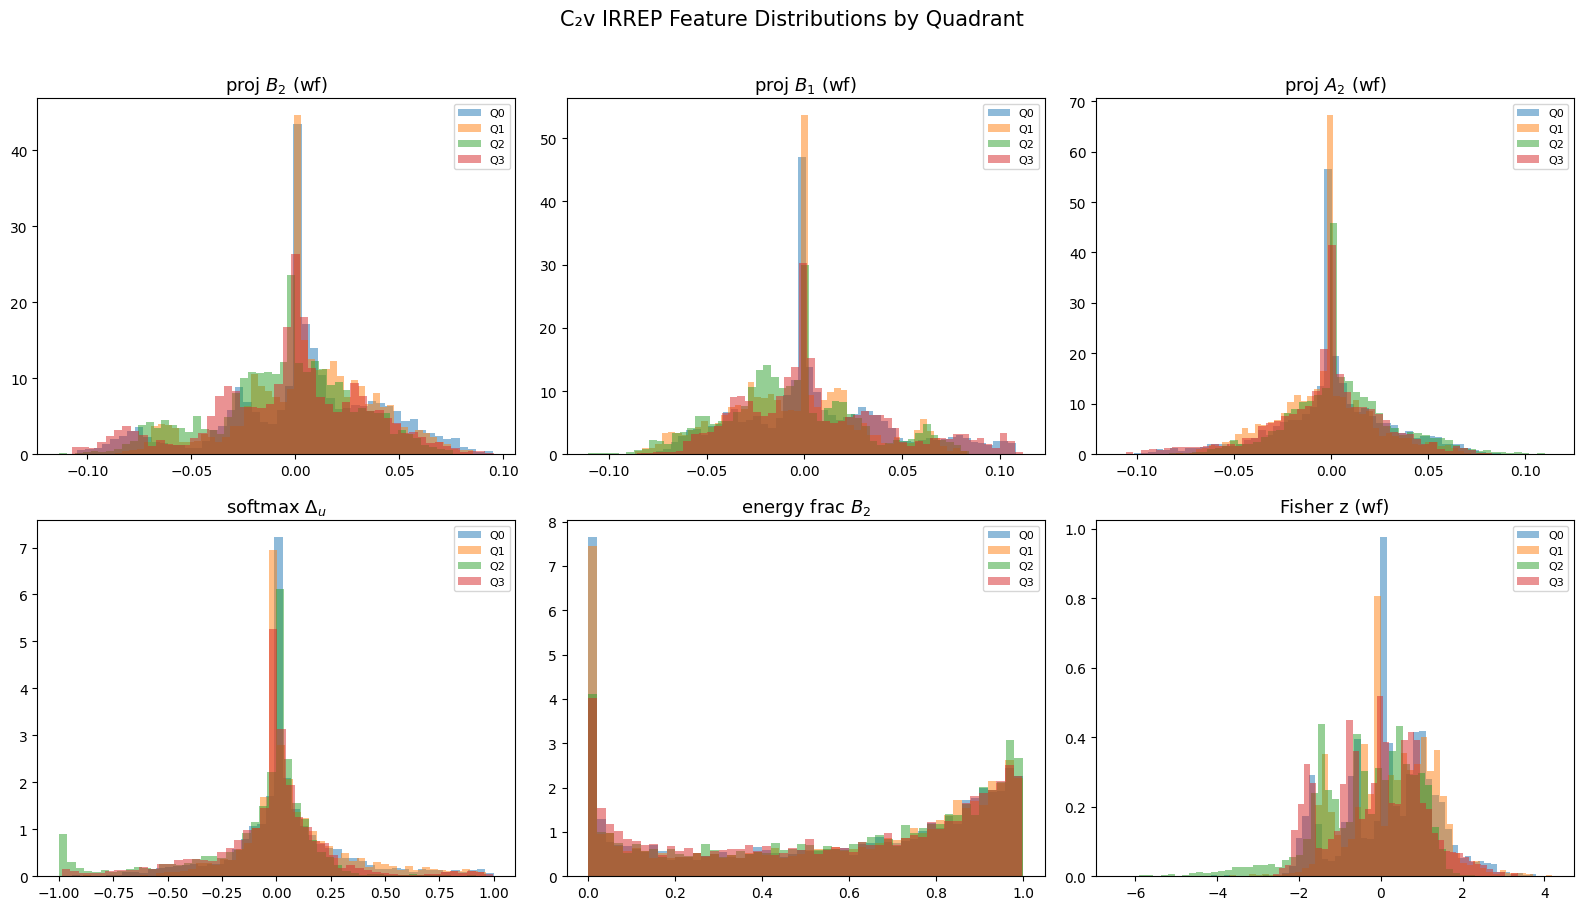

Legend: Q0=u>0,v>0 | Q1=u>0,v<0 | Q2=u<0,v<0 | Q3=u<0,v>0


In [8]:
# §6b  Visualisation of key IRREP features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Top row: direct projections (wf domain)
for ax, data, lbl in zip(axes[0],
    [proj_b2_wf, proj_b1_wf, proj_a2_wf],
    [r'proj $B_2$ (wf)', r'proj $B_1$ (wf)', r'proj $A_2$ (wf)']):
    for qi in range(4):
        m = q_all == qi
        ax.hist(data[m], bins=50, alpha=.5, density=True, label=f'Q{qi}')
    ax.set_title(lbl, fontsize=13)
    ax.legend(fontsize=8)

# Bottom row: softmax u-contrast, energy fraction B2, Fisher z (wf)
for ax, data, lbl in zip(axes[1],
    [sm_u, efrac_b2, fisher_z_wf],
    [r'softmax $\Delta_u$', r'energy frac $B_2$', r'Fisher z (wf)']):
    for qi in range(4):
        m = q_all == qi
        ax.hist(data[m], bins=50, alpha=.5, density=True, label=f'Q{qi}')
    ax.set_title(lbl, fontsize=13)
    ax.legend(fontsize=8)

fig.suptitle('C₂v IRREP Feature Distributions by Quadrant', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("Legend: Q0=u>0,v>0 | Q1=u>0,v<0 | Q2=u<0,v<0 | Q3=u<0,v>0")

## §7  Mutual Information Analysis

To quantify the **predictive power** of each feature independently, we compute the
mutual information (MI) between every feature and the quadrant label $q \in \{0,1,2,3\}$.
MI is a non-parametric, non-linear measure of statistical dependence:

$$I(X; Y) = \sum_{y} \int p(x,y)\,\log \frac{p(x,y)}{p(x)\,p(y)}\,dx$$

This ranking reveals which feature families contribute the most discriminative
information for the u-sign classification task — the main bottleneck of the
reconstruction (§6 showed that $B_2$ features capture the up/down asymmetry,
which directly encodes the u-sign).

Rank                        Feature      Group  MI (nats)
----------------------------------------------------------
   1                         radius     radius     0.2799
   2                 irrep_win_b2_5     irreps     0.1744
   3               irrep_fisher_z_0     irreps     0.1260
   4                 irrep_a2_pca_0     irreps     0.1113
   5               irrep_fisher_z_1     irreps     0.1055
   6                      fft_pca_0    fft_pca     0.1001
   7                      fft_pca_4    fft_pca     0.0840
   8                      fft_pca_5    fft_pca     0.0825
   9                 irrep_win_b2_2     irreps     0.0786
  10                 irrep_win_b2_1     irreps     0.0776
  11                      fft_pca_2    fft_pca     0.0739
  12                      fft_pca_7    fft_pca     0.0731
  13                      fft_pca_6    fft_pca     0.0716
  14            irrep_proj_direct_1     irreps     0.0701
  15                      fft_pca_1    fft_pca     0.0692
  16         

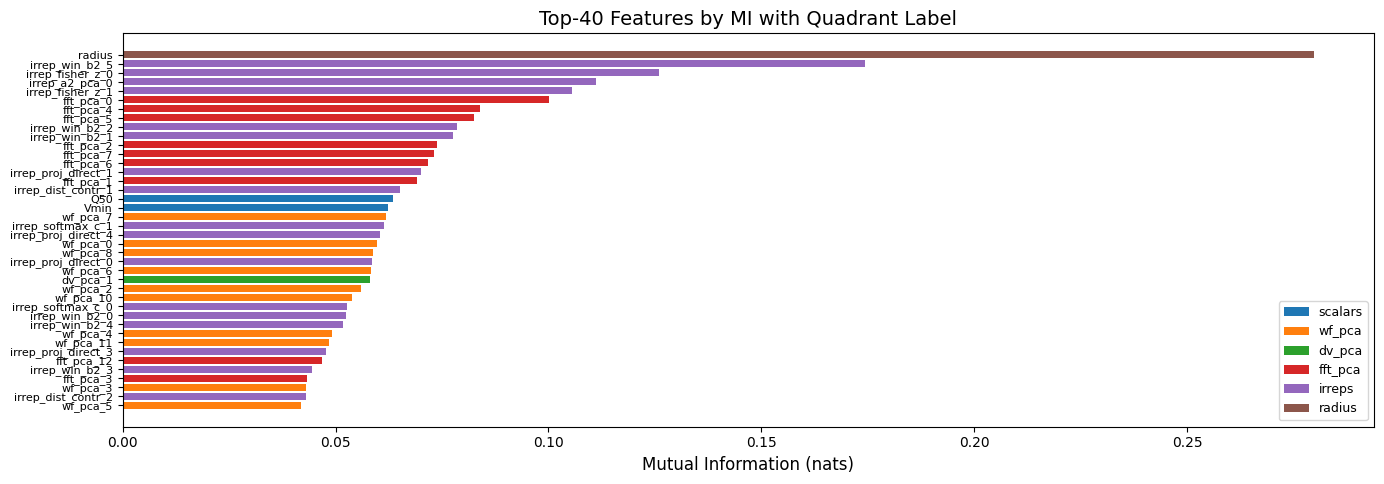


MI by feature group (mean ± std):
     scalars: 0.0312 ± 0.0196  (n=11)
      wf_pca: 0.0311 ± 0.0207  (n=25)
      dv_pca: 0.0087 ± 0.0136  (n=25)
     fft_pca: 0.0483 ± 0.0322  (n=15)
      irreps: 0.0483 ± 0.0379  (n=33)
      radius: 0.2799 ± 0.0000  (n=1)


In [9]:
# ============================================================
# §7a  Mutual information: features vs quadrant label
# ============================================================
from sklearn.feature_selection import mutual_info_classif

# Consolidate all feature blocks into a single array with labels
feature_groups = {}

# Scalar features (11)
scalar_labels = ['Vmin','Q50','ToA_50','ToT_50','RiseTime',
                 'ToA_25','ToA_75','dToA_50_25','tcoll_50','BlineRMS','iz']
feature_groups['scalars'] = (features[:, :11], scalar_labels)

# Waveform PCA (N_WF modes)
wf_labels = [f'wf_pca_{i}' for i in range(asym_wf.shape[1])]
feature_groups['wf_pca'] = (asym_wf, wf_labels)

# Derivative PCA (N_DV modes)
dv_labels = [f'dv_pca_{i}' for i in range(asym_deriv.shape[1])]
feature_groups['dv_pca'] = (asym_deriv, dv_labels)

# FFT PCA (N_FFT modes)
fft_labels = [f'fft_pca_{i}' for i in range(asym_fft.shape[1])]
feature_groups['fft_pca'] = (asym_fft, fft_labels)

# IRREP features
feature_groups['irreps'] = (irrep_all, irrep_feat_labels)

# Radius
feature_groups['radius'] = (r_all.reshape(-1,1), ['radius'])

# Stack all
all_feat_names = []
all_feat_arrays = []
all_feat_group_idx = []
group_color_map = {
    'scalars': '#1f77b4', 'wf_pca': '#ff7f0e', 'dv_pca': '#2ca02c',
    'fft_pca': '#d62728', 'irreps': '#9467bd', 'radius': '#8c564b'
}
for gi, (gname, (arr, names)) in enumerate(feature_groups.items()):
    all_feat_arrays.append(arr)
    all_feat_names.extend(names)
    all_feat_group_idx.extend([gname] * len(names))

X_all = np.hstack(all_feat_arrays)
y_quad = q_all.astype(int)

# Compute MI (using 5 neighbours, averaged over 3 seeds for stability)
mi_scores = np.zeros(X_all.shape[1])
for seed in [42, 123, 7]:
    mi_scores += mutual_info_classif(X_all, y_quad, n_neighbors=5, random_state=seed)
mi_scores /= 3

# Sort and display top features
order = np.argsort(mi_scores)[::-1]
print(f"{'Rank':>4} {'Feature':>30} {'Group':>10} {'MI (nats)':>10}")
print('-' * 58)
for rank, i in enumerate(order[:30]):
    print(f"{rank+1:4d} {all_feat_names[i]:>30} {all_feat_group_idx[i]:>10} {mi_scores[i]:10.4f}")

# --- Bar chart ---
top_k = min(40, len(mi_scores))
top_idx = order[:top_k]

fig, ax = plt.subplots(figsize=(14, 5))
colors = [group_color_map[all_feat_group_idx[i]] for i in top_idx]
ax.barh(range(top_k), mi_scores[top_idx], color=colors)
ax.set_yticks(range(top_k))
ax.set_yticklabels([all_feat_names[i] for i in top_idx], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information (nats)', fontsize=12)
ax.set_title(f'Top-{top_k} Features by MI with Quadrant Label', fontsize=14)

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(fc=c, label=n) for n, c in group_color_map.items()]
ax.legend(handles=legend_elems, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# Group-level summary
print("\nMI by feature group (mean ± std):")
for gname in feature_groups:
    mask = [g == gname for g in all_feat_group_idx]
    mi_g = mi_scores[mask]
    print(f"  {gname:>10}: {mi_g.mean():.4f} ± {mi_g.std():.4f}  (n={len(mi_g)})")

## §8  Feature Assembly, Scaling, and Dataset Export

This section assembles the final multi-domain feature set and prepares everything 
needed by the companion **NB_Model_Training** notebook. The pipeline:

1. **C₂v folding:** transform $(x, y)$ → $(|u|, |v|, r, q)$ in the fundamental domain
2. **Scaling:** RobustScaler for scalar features (outlier-safe), StandardScaler for 
   PCA modes, IRREP features, targets, and radius
3. **MLP input vector** ($d=110$): 11 scalars + 25 wf-PCA + 25 dV/dt-PCA + 
   15 FFT-PCA + 33 C₂v irreps + 1 radius
4. **CNN input tensor** ($2 \times 90$): per-event z-normalised waveform and derivative 
   stacked as a 2-channel 1-D "image"
5. **Spatial stratification split**: 80/20 within each scan position to guarantee 
   every grid point is represented in both train and test sets

The output is saved to `model_input.npz` — a single file containing all arrays and 
metadata the training notebook needs. No further feature engineering is required downstream.

In [10]:
# ============================================================
# §8a  C2v Folding, Scaling, Split, and Export
# ============================================================

# ── A) C₂v coordinate folding ────────────────────────────────
phi_r = np.radians(PHI0)
dx_c, dy_c = targets_xy[:, 0] - X_C, targets_xy[:, 1] - Y_C
u_all =  np.cos(phi_r) * dx_c + np.sin(phi_r) * dy_c   # ∥ trench
v_all = -np.sin(phi_r) * dx_c + np.cos(phi_r) * dy_c   # ⊥ trench

xf_all = np.abs(u_all)   # |u|
yf_all = np.abs(v_all)   # |v|
targets_fund = np.column_stack([xf_all, yf_all])   # fundamental domain

# U-sign label: 1 = u≥0 (Q0,Q1), 0 = u<0 (Q2,Q3)
u_sign = ((q_all == 0) | (q_all == 1)).astype(np.float32)

print(f"C₂v folding:")
print(f"  Fundamental domain: |u| ∈ [{xf_all.min():.2f}, {xf_all.max():.2f}]  "
      f"|v| ∈ [{yf_all.min():.2f}, {yf_all.max():.2f}] µm")
print(f"  Quadrant counts: {dict(zip(*np.unique(q_all, return_counts=True)))}")
print(f"  U-sign:  up={int(u_sign.sum())}, down={int(N - u_sign.sum())}")

# ── B) Feature scaling ────────────────────────────────────────
from sklearn.preprocessing import RobustScaler, StandardScaler

feat_scaler = RobustScaler()
feats_scaled = feat_scaler.fit_transform(features)

asym_wf_scaler    = StandardScaler(); asym_wf_scaled    = asym_wf_scaler.fit_transform(asym_wf)
asym_deriv_scaler = StandardScaler(); asym_deriv_scaled = asym_deriv_scaler.fit_transform(asym_deriv)
asym_fft_scaler   = StandardScaler(); asym_fft_scaled   = asym_fft_scaler.fit_transform(asym_fft)
irrep_scaler      = StandardScaler(); irrep_scaled      = irrep_scaler.fit_transform(irrep_all)
r_scaler          = StandardScaler(); r_scaled          = r_scaler.fit_transform(r_all.reshape(-1, 1))

# Target scaling
target_scaler = StandardScaler()
targets_fund_scaled = target_scaler.fit_transform(targets_fund)

# ── C) MLP input vector (110-d) ──────────────────────────────
mlp_input = np.concatenate([
    feats_scaled,           # 11  (RobustScaler)
    asym_wf_scaled,         # 25  (StandardScaler)
    asym_deriv_scaled,      # 25  (StandardScaler) — N_ASYM_DERIV
    asym_fft_scaled,        # 15  (StandardScaler)
    irrep_scaled,           # 33  (StandardScaler)
    r_scaled,               #  1  (StandardScaler)
], axis=1)
N_MLP_IN = mlp_input.shape[1]
print(f"\nMLP input: {mlp_input.shape}  ({N_MLP_IN}-d)")

# ── D) CNN input (2-channel waveform, per-event z-normalization) ─
wf_mean    = wf_roi.mean(axis=1, keepdims=True)
wf_std     = wf_roi.std(axis=1, keepdims=True).clip(min=1e-8)
wf_norm    = (wf_roi - wf_mean) / wf_std

deriv_mean = deriv_roi.mean(axis=1, keepdims=True)
deriv_std  = deriv_roi.std(axis=1, keepdims=True).clip(min=1e-8)
dv_norm    = (deriv_roi - deriv_mean) / deriv_std

cnn_input = np.stack([wf_norm, dv_norm], axis=1).astype(np.float32)  # (N, 2, 90)
print(f"CNN input: {cnn_input.shape}  (2-ch × {N_BINS} bins)")

# ── E) Spatial stratification split ──────────────────────────
# Split 80/20 within each spatial position to guarantee every
# grid point is represented in both train and test sets.
x_all, y_all = targets_xy[:, 0], targets_xy[:, 1]
spatial_key = np.round(x_all).astype(int) * 10000 + np.round(y_all).astype(int)
rng = np.random.RandomState(42)
idx_train_list, idx_test_list = [], []

for key in np.unique(spatial_key):
    group_idx = np.where(spatial_key == key)[0]
    n = len(group_idx)
    if n == 1:
        idx_train_list.append(group_idx)
    else:
        n_test = max(1, int(round(n * 0.2)))
        perm = rng.permutation(n)
        idx_test_list.append(group_idx[perm[:n_test]])
        idx_train_list.append(group_idx[perm[n_test:]])

idx_train = np.concatenate(idx_train_list); rng.shuffle(idx_train)
idx_test  = np.concatenate(idx_test_list);  rng.shuffle(idx_test)

train_keys = set(spatial_key[idx_train]); test_keys = set(spatial_key[idx_test])
print(f"\nSpatial stratification split:")
print(f"  Train: {len(idx_train):,} ({len(idx_train)/N:.1%})")
print(f"  Test:  {len(idx_test):,} ({len(idx_test)/N:.1%})")
print(f"  Positions in both sets: {len(train_keys & test_keys)}")

# ── F) Export everything to a single .npz ─────────────────────
export_path = os.path.join(SAVE_DIR, 'model_input.npz')
np.savez_compressed(export_path,
    # Model inputs (already scaled)
    mlp_input=mlp_input.astype(np.float32),   # (N, 110)
    cnn_input=cnn_input,                       # (N, 2, 90)
    # Targets
    targets_fund_scaled=targets_fund_scaled.astype(np.float32),  # (N, 2) scaled |u|,|v|
    targets_xy=targets_xy.astype(np.float32),                     # (N, 2) raw x,y
    targets_fund=targets_fund.astype(np.float32),                 # (N, 2) |u|,|v| unscaled
    # Labels
    quadrant=q_all.astype(np.int64),
    u_sign=u_sign.astype(np.float32),
    radius=r_all.astype(np.float32),
    # Split indices
    idx_train=idx_train,
    idx_test=idx_test,
    # Target scaler params (for inverse transform in training notebook)
    target_mean=target_scaler.mean_.astype(np.float32),
    target_scale=target_scaler.scale_.astype(np.float32),
    # Geometry
    geometry=np.array([X_C, Y_C, PHI0], dtype=np.float64),
    # Dimensions (stored as array for npz compatibility)
    dims=np.array([N_SCALARS, N_ASYM_WF, N_ASYM_DERIV, N_ASYM_FFT,
                    N_IRREP, N_MLP_IN, N_BINS, 4], dtype=np.int32),
    # dim labels: [n_scalars, n_wf_pca, n_dv_pca, n_fft_pca,
    #              n_irrep, n_mlp_in, n_bins, n_sectors]
)

size_mb = os.path.getsize(export_path) / 1e6
print(f"\nExported: {export_path}")
print(f"  File size: {size_mb:.1f} MB")
print(f"  Contents: mlp_input({N_MLP_IN}), cnn_input(2×{N_BINS}), "
      f"targets, labels, split, geometry")

C₂v folding:
  Fundamental domain: |u| ∈ [0.00, 41.61]  |v| ∈ [0.02, 37.52] µm
  Quadrant counts: {np.int64(0): np.int64(4466), np.int64(1): np.int64(4639), np.int64(2): np.int64(4295), np.int64(3): np.int64(4073)}
  U-sign:  up=9105, down=8368

MLP input: (17473, 110)  (110-d)
CNN input: (17473, 2, 90)  (2-ch × 90 bins)

Spatial stratification split:
  Train: 13,871 (79.4%)
  Test:  3,602 (20.6%)
  Positions in both sets: 3602

Exported: /kaggle/working/model_input.npz
  File size: 19.0 MB
  Contents: mlp_input(110), cnn_input(2×90), targets, labels, split, geometry


In [11]:
# §8b  Final feature summary table

print("=" * 70)
print("  FEATURE ENGINEERING SUMMARY")
print("=" * 70)

summary_rows = [
    ('Scalar features',         N_SCALARS,           'RobustScaler'),
    ('Waveform PCA modes',      asym_wf.shape[1],    'StandardScaler'),
    ('Derivative PCA modes',    asym_deriv.shape[1],  'StandardScaler'),
    ('FFT PCA modes',           asym_fft.shape[1],    'StandardScaler'),
    ('C2v IRREP features',      N_IRREP,              'StandardScaler'),
    ('Radial distance',         1,                    'StandardScaler'),
]
total = sum(r[1] for r in summary_rows)

print(f"\n  {'Block':>25} {'Dim':>5}  {'Scaling':<20}")
print(f"  {'-'*55}")
for name, dim, scl in summary_rows:
    print(f"  {name:>25} {dim:5d}  {scl:<20}")
print(f"  {'-'*55}")
print(f"  {'TOTAL MLP INPUT':>25} {total:5d}")
print(f"  {'CNN input':>25}    2 × {N_BINS}  (wf + dV/dt)")

print(f"\n  {'Events':>25} {N:5d}")
print(f"  {'Train / Test':>25} {len(idx_train):5d} / {len(idx_test):5d}")
print(f"  {'C2v groups (full)':>25} {n_full:5d}")
print(f"  {'C2v groups (usable)':>25} {n_usable:5d}")
print(f"  {'A2 PCA modes':>25} {N_A2:5d}")

print(f"\n  Target scaling:")
print(f"    mean = [{target_scaler.mean_[0]:.4f}, {target_scaler.mean_[1]:.4f}] µm")
print(f"    std  = [{target_scaler.scale_[0]:.4f}, {target_scaler.scale_[1]:.4f}] µm")

print(f"\n  Geometry:")
print(f"    Centre: ({X_C:.2f}, {Y_C:.2f}) µm")
print(f"    φ₀:     {PHI0:.2f}°")

print(f"\n  Output: model_input.npz ({size_mb:.1f} MB)")
print(f"  → Ready for NB_Model_Training (no further feature engineering needed)")
print("=" * 70)

  FEATURE ENGINEERING SUMMARY

                      Block   Dim  Scaling             
  -------------------------------------------------------
            Scalar features    11  RobustScaler        
         Waveform PCA modes    25  StandardScaler      
       Derivative PCA modes    25  StandardScaler      
              FFT PCA modes    15  StandardScaler      
         C2v IRREP features    33  StandardScaler      
            Radial distance     1  StandardScaler      
  -------------------------------------------------------
            TOTAL MLP INPUT   110
                  CNN input    2 × 90  (wf + dV/dt)

                     Events 17473
               Train / Test 13871 /  3602
          C2v groups (full)   766
        C2v groups (usable)   867
               A2 PCA modes     8

  Target scaling:
    mean = [15.3650, 13.7449] µm
    std  = [9.6919, 8.3387] µm

  Geometry:
    Centre: (-0.75, -1.46) µm
    φ₀:     89.27°

  Output: model_input.npz (19.0 MB)
  → Ready for 

---

## Summary

This notebook implements a complete **physics-informed feature engineering pipeline**
for sub-pixel position reconstruction in 3D silicon detectors using TPA-TCT data.

**Input:** 3 raw files — `tpa_tct_scalars.csv`, `tpa_tct_waveforms_roi.npz`, `metadata.json`  
**Output:** `model_input.npz` — everything the model training notebook needs

| Stage | Method | Output |
|-------|--------|--------|
| EDA | Distribution analysis, spatial mapping | Physical understanding of 11 base features |
| Waveform processing | dV/dt, FFT | Temporal derivative and spectral representations |
| Symmetry exploitation | C₂v group theory | Quadrant assignment, fundamental domain folding |
| Hierarchical PCA | Per-group asymmetry decomposition (all 3 domains) | 65 PCA modes (25 wf + 25 dV/dt + 15 FFT) |
| IRREP features | B₂/B₁/A₂ projections, Fisher z, variance contrast | 33 group-theoretic features |
| Feature selection | Mutual information ranking | Validated discriminative power of each block |
| Assembly & export | Scaling, C₂v folding, spatial stratification | 110-d MLP + 2×90 CNN ready for training |

---
*Author: Ibon García Gómez · Research Project · February 2026*